#Analisis exploratorio y limpieza 2

In [1]:
import pandas as pd
df = pd.read_csv('maternal_mortality.csv')


In [2]:
print(df.head())
print(df.columns.tolist())

  ISO3               Country Continent           Hemisphere  \
0  AFG           Afghanistan      Asia  Northern Hemisphere   
1  AGO                Angola    Africa  Southern Hemisphere   
2  ALB               Albania    Europe  Northern Hemisphere   
3  AND               Andorra    Europe  Northern Hemisphere   
4  ARE  United Arab Emirates      Asia  Northern Hemisphere   

  Human Development Groups UNDP Developeing Regions  HDI Rank (2021)  \
0                      Low                       SA            180.0   
1                   Medium                      SSA            148.0   
2                     High                      ECA             67.0   
3                Very High                      NaN             40.0   
4                Very High                       AS             26.0   

   Maternal Mortality Ratio (deaths per 100,000 live births) (1990)  \
0                                             1500.0                  
1                                             

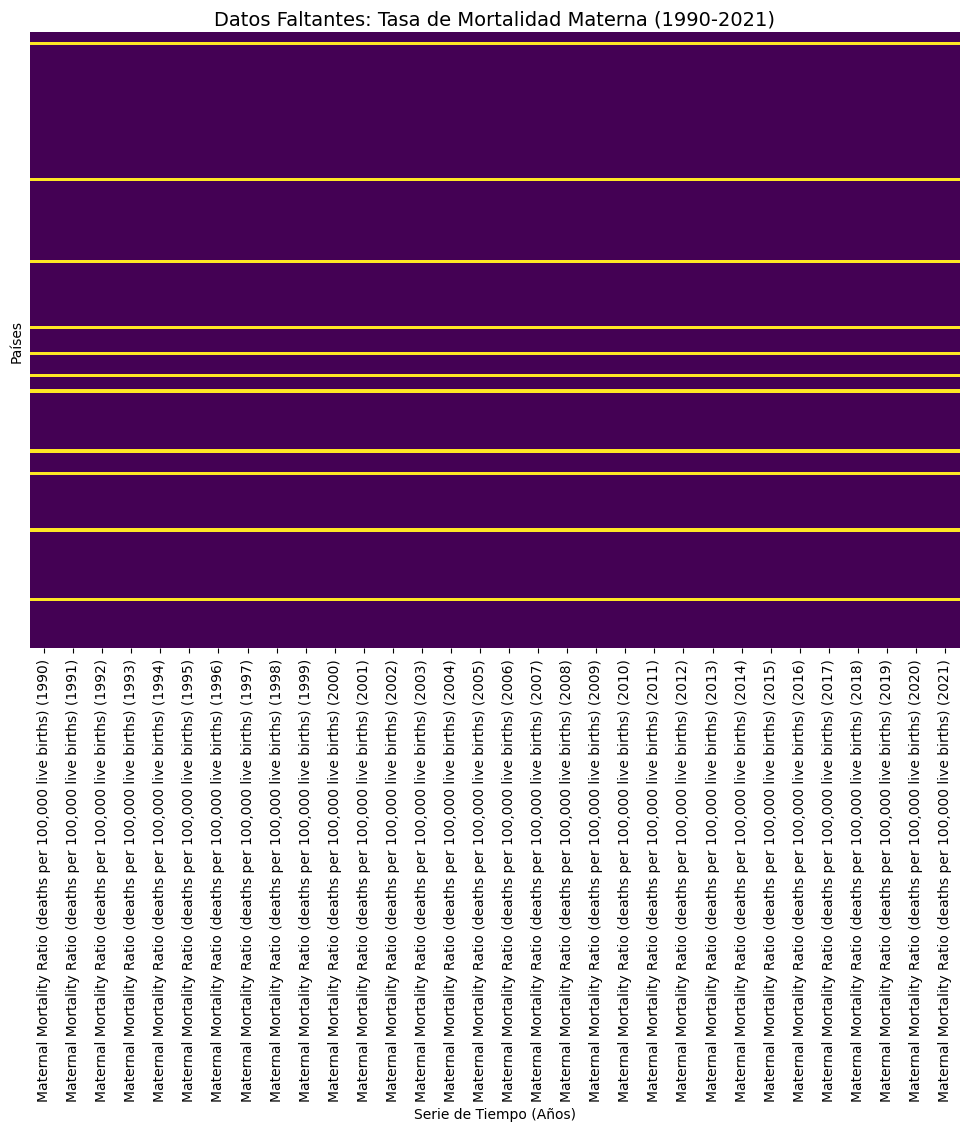

Total de datos faltantes en la serie: 352


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las columnas que contienen la tasa de mortalidad
# Usamos un filtro para no escribir los nombres largos uno por uno
cols_mortalidad = [c for c in df.columns if 'Maternal Mortality Ratio' in c]

# Creamos el mapa de calor de nulos
plt.figure(figsize=(12, 8))
sns.heatmap(df[cols_mortalidad].isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Datos Faltantes: Tasa de Mortalidad Materna (1990-2021)', fontsize=14)
plt.xlabel('Serie de Tiempo (Años)')
plt.ylabel('Países')
plt.show()

# ¿Cuántos nulos hay realmente?
nulos_por_columna = df[cols_mortalidad].isnull().sum()
print("Total de datos faltantes en la serie:", nulos_por_columna.sum())

Eje X (Horizontal): Años, de 1990 a 2021.

Eje Y (Vertical): Representa cada fila individual, es decir, cada país. Cada "rayita" horizontal es un país diferente.

Una línea amarilla que va desde 1990 hasta 2021 sin interrupciones, significa que ese país no tiene ni un solo dato de MMR en toda la serie histórica.
Implicación Metodológica: Para ese país en específico, la fuente de datos (UNDP/OMS) no pudo realizar ni siquiera una estimación basada en modelos, probablemente por falta absoluta de censos o por ser territorios con registros administrativos inexistentes.

In [4]:
# Identificamos las columnas de mortalidad (sin los Rankings)
cols_mortalidad = [c for c in df.columns if 'Maternal Mortality Ratio' in c and 'Rank' not in c]

#Filtramos el DataFrame para ver SOLO los países que tienen TODO nulo en esas columnas
paises_con_nulos = df[df[cols_mortalidad].isnull().all(axis=1)]

# Mostramos la lista de nombres
print(f"Se identificaron {len(paises_con_nulos)} países con datos totalmente faltantes:")
print(paises_con_nulos['Country'].tolist())

Se identificaron 11 países con datos totalmente faltantes:
['Andorra', 'Dominica', 'Hong Kong', 'Saint Kitts and Nevis', 'Liechtenstein', 'Monaco', 'Marshall Islands', 'Nauru', 'Palau', 'San Marino', 'Tuvalu']


En el presente análisis, se identificaron 11 unidades territoriales (Andorra, Dominica, Hong Kong, entre otras) con ausencia total de registros en la serie histórica de mortalidad materna (1990-2021). Según los criterios del Grupo Interinstitucional para la Estimación de la Mortalidad Materna (MMEIG) de las Naciones Unidas, estas omisiones no representan necesariamente una falta de gestión administrativa, sino que responden a estándares de fiabilidad estadística. En microestados y poblaciones pequeñas, la ocurrencia de un solo deceso materno genera fluctuaciones extremas en la Tasa de Mortalidad Materna (MMR) por cada 100,000 nacidos vivos, lo que invalidaría la representatividad de la tendencia. Asimismo, organismos como la OMS y el Banco Mundial señalan que la falta de sistemas consolidados de Registro Civil y Estadísticas Vitales (CRVS) en ciertas regiones insulares impide la generación de estimaciones robustas comparables a nivel internacional, optando por la exclusión de estos datos para evitar sesgos en las medias globales

In [5]:
#Definimos las columnas de interés
cols_mortalidad = [c for c in df.columns if 'Maternal Mortality Ratio' in c and 'Rank' not in c]

# Identificamos a los 11 países (ya lo hicimos, pero aquí lo automatizamos)
paises_a_eliminar = df[df[cols_mortalidad].isnull().all(axis=1)]['Country'].tolist()

# Creamos el nuevo DataFrame filtrado
# dropna con how='all' elimina la fila solo si TODOS los valores en 'subset' son NaN
df_limpio = df.dropna(subset=cols_mortalidad, how='all').copy()

# Verificación final de integridad
print(f"--- REPORTE DE LIMPIEZA ---")
print(f"Países inicialmente cargados: {len(df)}")
print(f"Países eliminados (sin datos): {len(paises_a_eliminar)}")
print(f"Países listos para análisis: {len(df_limpio)}")
print(f"¿Quedan nulos en la serie de tiempo?: {df_limpio[cols_mortalidad].isnull().sum().sum()}")

--- REPORTE DE LIMPIEZA ---
Países inicialmente cargados: 195
Países eliminados (sin datos): 11
Países listos para análisis: 184
¿Quedan nulos en la serie de tiempo?: 0


**Exploracion de otros valores faltantes**

In [6]:
# Revisión general de todas las columnas
print("--- REVISIÓN DE NULOS POR COLUMNA ---")
print(df_limpio.isnull().sum()[df_limpio.isnull().sum() > 0])

# Revisión específica de columnas de clasificación
cols_identidad = ['Continent', 'Hemisphere', 'Human Development Groups', 'UNDP Developeing Regions']
print("\n--- NULOS EN COLUMNAS DE CLASIFICACIÓN ---")
for col in cols_identidad:
    nulos = df_limpio[col].isnull().sum()
    print(f"{col}: {nulos} nulos")

--- REVISIÓN DE NULOS POR COLUMNA ---
Human Development Groups     2
UNDP Developeing Regions    39
HDI Rank (2021)              2
dtype: int64

--- NULOS EN COLUMNAS DE CLASIFICACIÓN ---
Continent: 0 nulos
Hemisphere: 0 nulos
Human Development Groups: 2 nulos
UNDP Developeing Regions: 39 nulos


El caso de UNDP Developing Regions (39 nulos)
No es un error. Estos 39 países son probablemente economías desarrolladas (como Noruega, Suiza o Estados Unidos) que el PNUD no clasifica dentro de sus "Regiones en Desarrollo" (como SSA para África Subsahariana o LAC para América Latina). Estos nulos tienen significado informativo: indican que el país es una economía avanzada.

Human Development Groups y HDI Rank (2021) (2 nulos cada uno)
Significa que hay 2 países en la lista que tienen datos de mortalidad materna, pero por alguna razón no tienen asignado un Índice de Desarrollo Humano (IDH) para 2021.


In [7]:
# Buscamos los países que no tienen grupo de desarrollo humano
paises_sin_idh = df_limpio[df_limpio['Human Development Groups'].isnull()]
print("Países sin clasificación de Desarrollo Humano (HDI):")
print(paises_sin_idh[['Country', 'ISO3']])

Países sin clasificación de Desarrollo Humano (HDI):
         Country ISO3
142  North Korea  PRK
158      Somalia  SOM


In [8]:
# Buscamos nulos en TODAS las columnas que empiezan con "Maternal Mortality..."
cols_mortalidad = [c for c in df_limpio.columns if 'Maternal Mortality Ratio' in c]

# Sumamos los nulos por cada año
nulos_por_año = df_limpio[cols_mortalidad].isnull().sum()

print("Nulos encontrados por año de mortalidad:")
print(nulos_por_año[nulos_por_año > 0])

Nulos encontrados por año de mortalidad:
Series([], dtype: int64)


In [9]:
# Creamos el DataFrame final eliminando las filas con nulos en HDI
# Reduciendo lista de 184 a 182 países
df_estudio = df_limpio.dropna(subset=['Human Development Groups', 'HDI Rank (2021)']).copy()

# Verificación de limpieza total
print("--- ESTADO FINAL DEL DATASET ---")
print(f"Países totales para el análisis: {len(df_estudio)}")
print(f"Nulos restantes en HDI: {df_estudio['HDI Rank (2021)'].isnull().sum()}")
print(f"Nulos restantes en Grupos de Desarrollo: {df_estudio['Human Development Groups'].isnull().sum()}")

# Un vistazo a cómo quedaron las categorías
print("\nConteo de países por Grupo de Desarrollo:")
print(df_estudio['Human Development Groups'].value_counts())

--- ESTADO FINAL DEL DATASET ---
Países totales para el análisis: 182
Nulos restantes en HDI: 0
Nulos restantes en Grupos de Desarrollo: 0

Conteo de países por Grupo de Desarrollo:
Human Development Groups
Very High    62
High         46
Medium       42
Low          32
Name: count, dtype: int64


**Se observa que algunos países repiten el mismo valor de MMR durante 5 años seguidos. Metodológicamente, esto qué significa? la fuente original usó estimaciones o proyecciones? Cómo se deben tratar esos valores?**

Cuando la fuente (OMS/BM) no tiene un dato nuevo validado para los años más recientes, aplica un método donde mantiene la última estimación confiable o proyecta una tendencia plana hasta que surja nueva evidencia. Por eso bloques de 4 o 5 años con el mismo número.

Metodologicamente significa que no se puede hacer del todo un analisis de volatilidad año con añom porque el dato no esta oscilando como lo haria en realidad sino que esta estancado por diseño administrativo. El cambio real de los paises con valores repetidos no ha sido capturado,

Entonces, en lugar de analizar cada año, podemos comparar extremos 1990vs2021. O, en el caso de este proyecto, comparar 10 años


In [10]:
# 1. Seleccionamos todas las columnas de años (1990-2021)
cols_mortalidad = [c for c in df_estudio.columns if 'Maternal Mortality Ratio' in c and 'Rank' not in c]

# 2. Calculamos métricas de variabilidad por país
# nunique: cuántos valores distintos ha reportado en 32 años
# count: cuántos datos tiene en total (debería ser 32)
df_estudio['valores_distintos'] = df_estudio[cols_mortalidad].nunique(axis=1)
df_estudio['años_totales'] = df_estudio[cols_mortalidad].count(axis=1)

# 3. Calculamos el % de "estancamiento" o repetición
# Si un país tiene 32 años de datos pero solo 5 valores distintos,
# significa que repite datos muy seguido.
df_estudio['indice_repeticion'] = (1 - (df_estudio['valores_distintos'] / df_estudio['años_totales'])) * 100

# 4. Identificamos casos críticos
casos_criticos = df_estudio.sort_values(by='indice_repeticion', ascending=True) # Los que MENOS cambian

print("--- REPORTE DE REPETICIÓN DE DATOS (1990-2021) ---")
print(f"Promedio de valores distintos por país: {df_estudio['valores_distintos'].mean():.1f} de 32 posibles.")

print("\nPaíses con MENOR variabilidad (Datos más repetidos/estáticos):")
print(casos_criticos[['Country', 'valores_distintos', 'indice_repeticion']].head(15))

--- REPORTE DE REPETICIÓN DE DATOS (1990-2021) ---
Promedio de valores distintos por país: 19.8 de 32 posibles.

Países con MENOR variabilidad (Datos más repetidos/estáticos):
                                  Country  valores_distintos  \
34                               Cameroon                 28   
154                       Solomon Islands                 28   
107                               Morocco                 28   
110                            Madagascar                 28   
26                                 Bhutan                 28   
52                                Eritrea                 28   
151                                 Sudan                 28   
117                               Myanmar                 28   
119                              Mongolia                 28   
144                              Paraguay                 28   
120                            Mozambique                 28   
123                                Malawi               

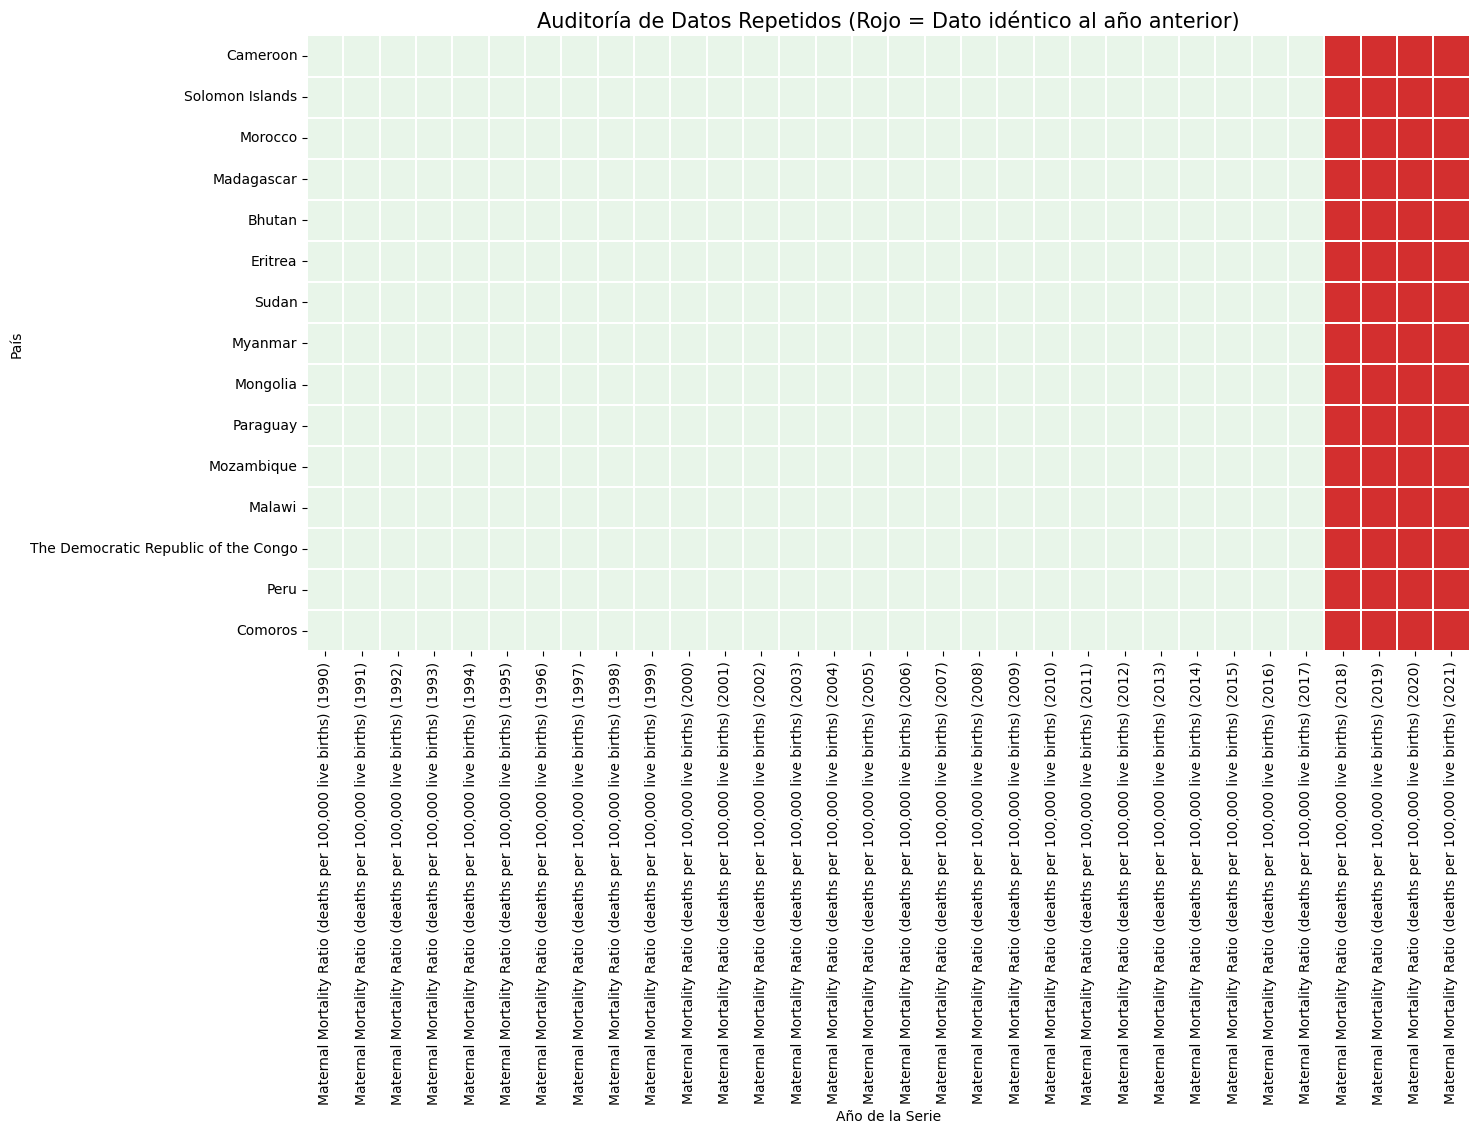

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionamos los años de la serie (1990-2021)
cols_mortalidad = [c for c in df_estudio.columns if 'Maternal Mortality Ratio' in c and 'Rank' not in c]

# 2. Creamos una máscara booleana: True si el valor es igual al del año anterior
# .diff() calcula la diferencia; si es 0, es que el dato se repitió.
df_repeticiones = df_estudio[cols_mortalidad].diff(axis=1) == 0

# 3. Filtramos para ver solo los 15 países que observamos antes
indices_criticos = casos_criticos.head(15).index
df_criticos_rep = df_repeticiones.loc[indices_criticos]
df_criticos_rep.index = df_estudio.loc[indices_criticos, 'Country']

# 4. Graficamos
plt.figure(figsize=(15, 8))
sns.heatmap(df_criticos_rep, cbar=False, cmap=['#e8f5e9', '#d32f2f'], linewidths=0.1)
plt.title('Auditoría de Datos Repetidos (Rojo = Dato idéntico al año anterior)', fontsize=15)
plt.xlabel('Año de la Serie')
plt.ylabel('País')
plt.show()



Los 4 cuadros rojos al final (2018, 2019, 2020 y 2021) significan que esos años son copias exactas del valor de 2017. Son 5 años con el mismo dato (el original de 2017 + 4 repeticiones). Sesde 1990 hasta 2017 casi todo es verde. Significa que la serie de tiempo sí tiene movimiento real en el 85% de su extensión. El problema no es el dataset completo, sino el reporte de los últimos 5 años.

--- ESTADÍSTICOS GLOBALES 2021 ---
count     182.000000
mean      156.741758
std       228.891333
min         2.000000
25%        12.250000
50%        52.500000
75%       185.750000
max      1150.000000
Name: Maternal Mortality Ratio (deaths per 100,000 live births) (2021), dtype: float64
Sesgo (Skewness): 2.21


/tmp/ipykernel_6026/46890375.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Human Development Groups', y=col_2021, data=df_estudio,


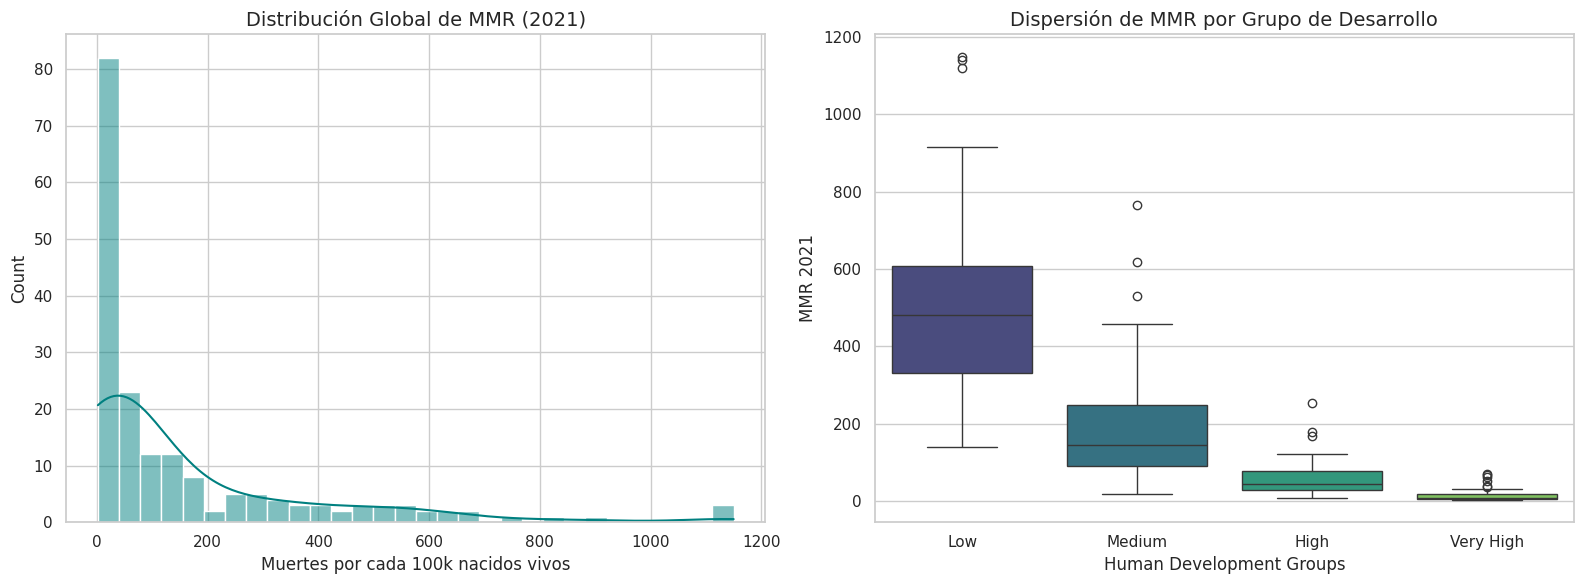

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
col_2021 = 'Maternal Mortality Ratio (deaths per 100,000 live births) (2021)'

# --- ESTADÍSTICOS DESCRIPTIVOS ---
print("--- ESTADÍSTICOS GLOBALES 2021 ---")
stats = df_estudio[col_2021].describe()
print(stats)
print(f"Sesgo (Skewness): {df_estudio[col_2021].skew():.2f}")

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma (Distribución General)
sns.histplot(df_estudio[col_2021], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución Global de MMR (2021)', fontsize=14)
axes[0].set_xlabel('Muertes por cada 100k nacidos vivos')

# Boxplot (Comparación por Grupos de Desarrollo)
sns.boxplot(x='Human Development Groups', y=col_2021, data=df_estudio,
            order=['Low', 'Medium', 'High', 'Very High'], palette='viridis', ax=axes[1])
axes[1].set_title('Dispersión de MMR por Grupo de Desarrollo', fontsize=14)
axes[1].set_ylabel('MMR 2021')

plt.tight_layout()
plt.show()

Sesgo (Skewness) de 2.21 confirma que no estamos ante una distribución normal, sino ante una con una "cola" larguísima hacia la derecha.

La media es casi 3 veces mayor que la mediana. Hay países con mortalidades de hasta 1,150 (el máximo) que "inflan" el promedio. En este dataset, la mediana es una medida mucho más honesta de la realidad de un país típico que el promedio.

Grupos "Very High" y "High": Son cajas casi planas, pegadas al cero. Significa que en estos niveles de desarrollo, la mortalidad materna está bajo control y es muy uniforme.

Grupo "Low": La caja es enorme. Esto indica que, dentro de los países pobres, hay algunos que están logrando avances y otros que están estancados en el desastre.

Outliers (Los puntos arriba): Esos puntos son países que "traicionan" su categoría. Por ejemplo, un país en el grupo "Medium" que tiene una mortalidad digna de un país "Low".

Este sesgo de 2.21 justifica por qué no se deberia usar modelos de regresión lineal simple sin antes aplicar una transformación logarítmica a la variable de mortalidad. De no realizarse, los países con 1,000 muertes dominarán todo el modelo y los resultados de los países desarrollados se perderán en el ruido.

Media: $156.7$Mediana (50%): $52.5$Cuando la media es casi el triple que la mediana, es la prueba matemática de que los países con alta mortalidad están "jalando" el promedio hacia arriba.

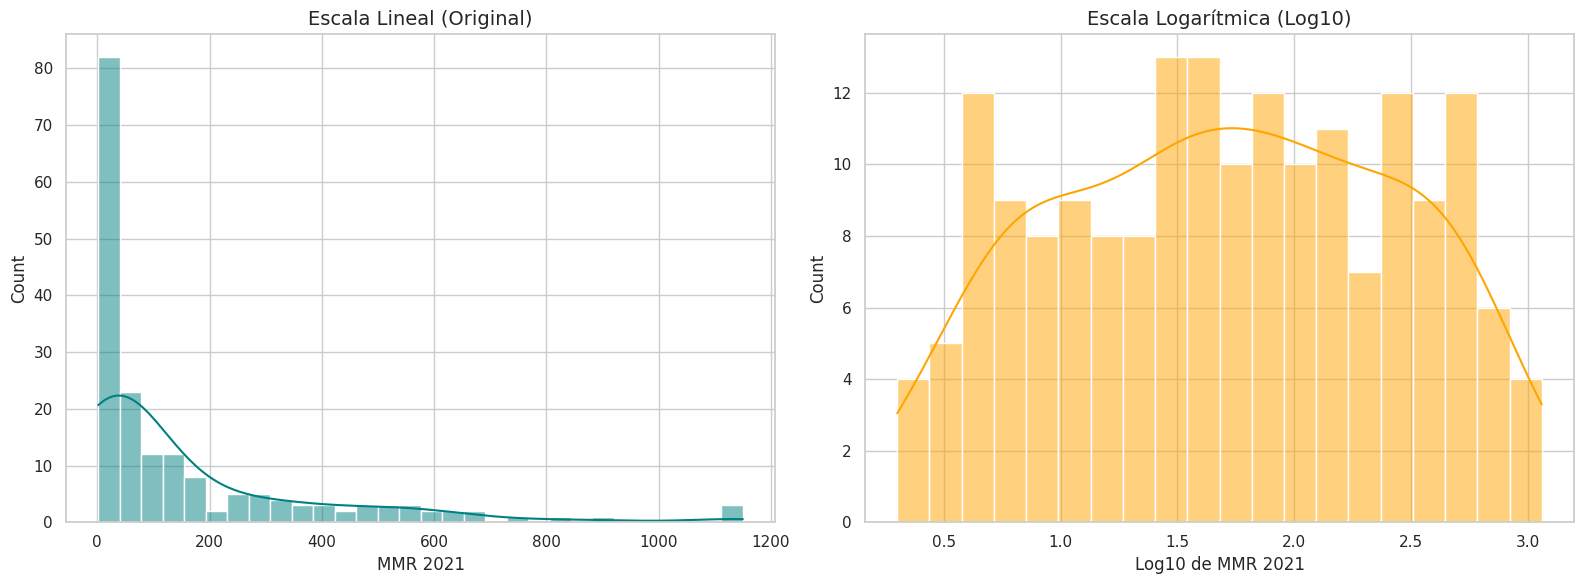

Sesgo Original: 2.21
Nuevo Sesgo (Log): -0.06


In [13]:
import numpy as np

# Creamos la columna logarítmica
df_estudio['log_MMR_2021'] = np.log10(df_estudio[col_2021])

# Visualizamos la diferencia
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma Original (Lineal)
sns.histplot(df_estudio[col_2021], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Escala Lineal (Original)', fontsize=14)
axes[0].set_xlabel('MMR 2021')

# Histograma Transformado (Logarítmico)
sns.histplot(df_estudio['log_MMR_2021'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Escala Logarítmica (Log10)', fontsize=14)
axes[1].set_xlabel('Log10 de MMR 2021')

plt.tight_layout()
plt.show()

# Nuevo Sesgo (Skewness)
print(f"Sesgo Original: {df_estudio[col_2021].skew():.2f}")
print(f"Nuevo Sesgo (Log): {df_estudio['log_MMR_2021'].skew():.2f}")

La transformacion logaritmica convirtio o normalizo un poco los datos, permitiendonos estar cerca del supuesto de normalidad de los residuos. Dado que la Razón de Mortalidad Materna presenta una distribución con un fuerte sesgo a la derecha, se aplicó una transformación logarítmica. Esto permite estabilizar la varianza y asegurar que los países con valores extremos no dominen desproporcionadamente la formación de los clusters, permitiendo una clasificación más equitativa.

Ahora que la variable de mortalidad está logaritmizada, el Scatter Plot nos va a revelar qué tan fuerte es la condena del subdesarrollo sobre la vida de las madres. Es decir, buscaremos la correlacion entre HDI Rank y log_MMR_2021

En economía, esto es lo que llamamos buscar la correlación estructural. Vamos a graficar el HDI Rank (X) contra nuestro log_MMR_2021 (Y).

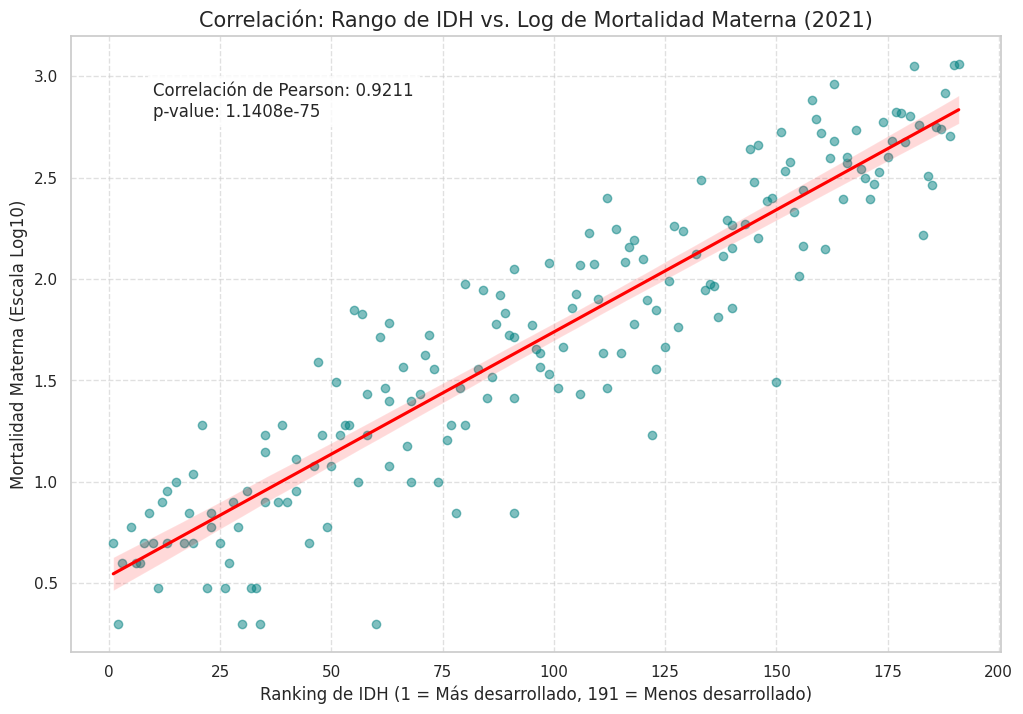

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración del gráfico
plt.figure(figsize=(12, 8))

# Creamos el scatter plot con una línea de regresión (regplot)
sns.regplot(x='HDI Rank (2021)', y='log_MMR_2021', data=df_estudio,
            scatter_kws={'alpha':0.5, 'color':'teal'},
            line_kws={'color':'red', 'label':'Tendencia Lineal'})

# Personalización
plt.title('Correlación: Rango de IDH vs. Log de Mortalidad Materna (2021)', fontsize=15)
plt.xlabel('Ranking de IDH (1 = Más desarrollado, 191 = Menos desarrollado)')
plt.ylabel('Mortalidad Materna (Escala Log10)')
plt.grid(True, linestyle='--', alpha=0.6)

# Calculamos el coeficiente de correlación de Pearson para el reporte
r, p_value = stats.pearsonr(df_estudio['HDI Rank (2021)'], df_estudio['log_MMR_2021'])
plt.text(10, 2.8, f'Correlación de Pearson: {r:.4f}\np-value: {p_value:.4e}',
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

Básicamente, el HDI Rank explica casi por completo la variación en la mortalidad materna. Existe una relación lineal positiva casi perfecta entre el ranking y el logaritmo de la mortalidad.A medida que un país "empeora" en el ranking (se mueve a la derecha hacia el 180), la mortalidad materna sube de forma exponencial (porque el eje Y es logarítmico). El p-value de $0.00e+00$ indica que la probabilidad de que esta relación sea producto del azar es casi cero.

Los que están "Arriba" de la línea (Outliers Negativos): Son países que tienen un ranking de desarrollo aceptable pero una mortalidad más alta de lo que "deberían" tener según la tendencia global. Estos puntos representan ineficiencias graves en sus sistemas de salud materna específicos.

Los que están "Abajo" de la línea (Sobre-rendidores): Son los puntos que están notablemente por debajo de la línea roja. Estos países están logrando "comprar" más salud materna con menos presupuesto/desarrollo de lo que predice el modelo. Son ejemplos de eficiencia.

In [15]:
print(df_estudio.columns.tolist())

['ISO3', 'Country', 'Continent', 'Hemisphere', 'Human Development Groups', 'UNDP Developeing Regions', 'HDI Rank (2021)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1990)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1991)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1992)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1993)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1994)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1995)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1996)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1997)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1998)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1999)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (2000)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (2001)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (20

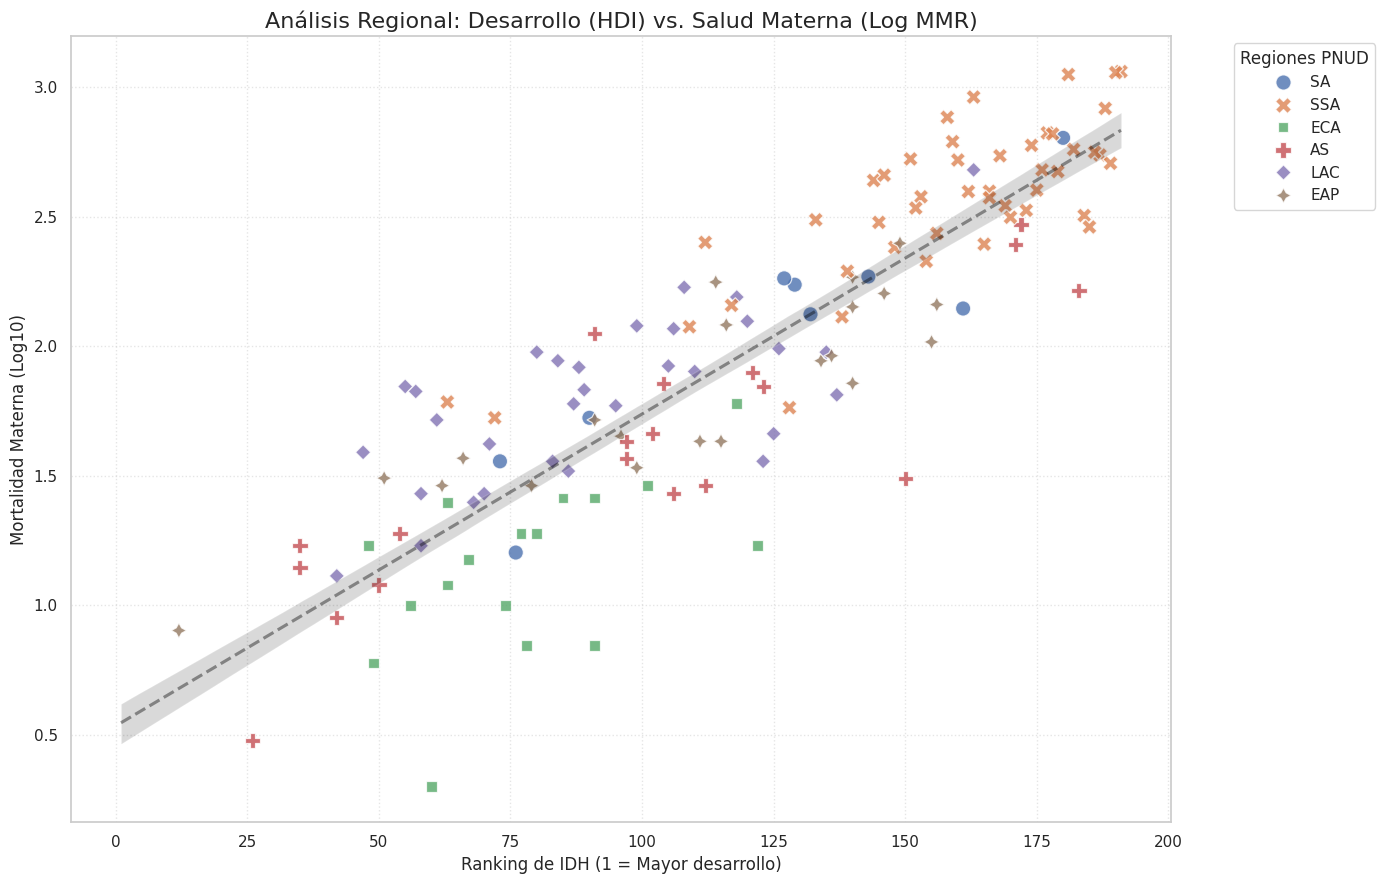

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del gráfico
plt.figure(figsize=(14, 9))
sns.scatterplot(x='HDI Rank (2021)', y='log_MMR_2021',
                hue='UNDP Developeing Regions',
                style='UNDP Developeing Regions',
                data=df_estudio, s=120, alpha=0.8)

# Línea de tendencia global para referencia
sns.regplot(x='HDI Rank (2021)', y='log_MMR_2021', data=df_estudio,
            scatter=False, color='black', line_kws={'linestyle':'--', 'alpha':0.4})

# Estética
plt.title('Análisis Regional: Desarrollo (HDI) vs. Salud Materna (Log MMR)', fontsize=16)
plt.xlabel('Ranking de IDH (1 = Mayor desarrollo)', fontsize=12)
plt.ylabel('Mortalidad Materna (Log10)', fontsize=12)
plt.legend(title='Regiones PNUD', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

1. El Bloque de África Subsahariana (SSA) - Naranja
Están concentrados en la parte superior derecha. Lo interesante aquí es que la mayoría de los puntos naranja están por encima de la línea punteada.
Esto significa que, para su nivel de desarrollo (IDH), tienen una mortalidad materna más alta de la que predice el modelo global. Hay factores estructurales o de acceso que el IDH no alcanza a capturar.

2. América Latina y el Caribe (LAC) - Verde
Casi todos están tocando o por debajo de la línea de tendencia.
LAC es una región relativamente "eficiente". Con el mismo ranking de IDH que algunos países de otras regiones, logramos mantener la mortalidad materna en niveles más bajos.

3. Los "Outliers" de Europa y Asia Central (ECA) - Azul
Están agrupados en la esquina inferior izquierda (bajo ranking, baja mortalidad), lo cual es lógico. Sin embargo, hay mucha uniformidad; casi no hay puntos azules que se escapen hacia arriba.

#Semaforo
**Objetivo de Desarrollo Sostenible 3 (Salud y Bienestar)**

Meta 3.1. En 2015, las Naciones Unidas y todos los países miembros acordaron que para el año 2030, la razón de mortalidad materna (MMR) a nivel mundial debe reducirse a menos de 70.

https://www.who.int/data/gho/data/themes/topics/sdg-target-3-1-maternal-mortality

In [17]:
import pandas as pd
import numpy as np

# 1. Definimos las columnas de interés ventana de 10 años
col_1990 = 'Maternal Mortality Ratio (deaths per 100,000 live births) (1990)'
col_2011 = 'Maternal Mortality Ratio (deaths per 100,000 live births) (2011)'
col_2021 = 'Maternal Mortality Ratio (deaths per 100,000 live births) (2021)'

# 2. Calculamos el Progreso Histórico (%) - Referencia desde 1990
df_estudio['Progreso_Total_Pct'] = ((df_estudio[col_1990] - df_estudio[col_2021]) / df_estudio[col_1990]) * 100

# 3. Calculamos el Cambio en la última década (2011-2021)
# Un valor negativo indica REDUCCIÓN de muertes (Progreso)
# Un valor de 0 indica estancamiento en los 10 años
df_estudio['Cambio_Decada_Pct'] = ((df_estudio[col_2021] - df_estudio[col_2011]) / df_estudio[col_2011]) * 100

# 4. Lógica del Semáforo
def asignar_semaforo_decada(row):
    # VERDE: Cumple Meta ODS (<= 70) Y ha bajado o se mantuvo igual en la última década
    if row[col_2021] <= 70 and row['Cambio_Decada_Pct'] <= 0:
        return 'VERDE'

    # AMARILLO: Entre 70 y 140 (Cerca de la meta)
    # O ha tenido un progreso histórico muy alto (>50%) aunque sea lento actualmente
    elif row[col_2021] <= 140 or row['Progreso_Total_Pct'] > 50:
        return 'AMARILLO'

    # ROJO: Mayor a 140 Y/O ha tenido retrocesos (aumento de muertes) en la última década
    else:
        return 'ROJO'

# Aplicamos
df_estudio['Semaforo'] = df_estudio.apply(asignar_semaforo_decada, axis=1)

# Ver resumen de resultados con la nueva ventana de tiempo
print("--- RESUMEN SEMÁFORO (Basado en última década 2011-2021) ---")
print(df_estudio['Semaforo'].value_counts())

--- RESUMEN SEMÁFORO (Basado en última década 2011-2021) ---
Semaforo
VERDE       94
AMARILLO    60
ROJO        28
Name: count, dtype: int64


**Lógica del semáforo**

**Las Condiciones (El "Criterio Técnico")**
El semáforo se construye evaluando tres variables críticas para cada país:

1. Estado Actual (MMR 2021): ¿Dónde está el país hoy respecto a la meta de los  Objetivos de Desarrollo Sostenible (ODS), que es tener menos de 70 muertes?
2. Esfuerzo Decenal (Cambio 2011-2021): ¿El país ha mejorado, se ha estancado o ha retrocedido en los últimos 10 años?
3. Memoria Histórica (Progreso desde 1990): ¿Qué tanto terreno ha ganado el país en las últimas tres décadas?

**Que representa cada color**

VERDE: "En la Ruta Correcta" (94 países) Representa a los países que han logrado controlar el problema.
Condición: Deben tener una tasa igual o menor a 70 (Meta ODS) Y mostrar que en la última década la cifra bajó o se mantuvo estable (Cambio <= 0%).

Son países con sistemas de salud robustos o en franca mejora que ya cumplen con los estándares internacionales.

AMARILLO: "Zona de Transición o Alerta de Estancamiento" (60 países). Es el grupo más diverso y representa una situación ambivalente.
Condición A: Países con MMR entre 70 y 140. Están cerca de la meta, pero aún no llegan.
Condición B: Países que quizás tienen tasas altas, pero que han demostrado un esfuerzo histórico brutal (reducción de más del 50% desde 1990).

Países que están trabajando bien pero necesitan un empujón final, o países que progresaron mucho pero se han "frenado" recientemente.

ROJO: "Estado de Emergencia" (28 países). Representa una crisis de salud pública y falta de progreso.

Condición A: Tasas de mortalidad superiores a 140 (el doble de la meta ODS).
Condición B: Países que han tenido retrocesos (la mortalidad subió en la última década, Cambio > 0%).

Países donde el desarrollo humano no se está traduciendo en seguridad para las madres. Aquí es donde el análisis debe ser más profundo.V



In [18]:
# 1. Creamos la tabla de contingencia
pivot_semaforo = pd.crosstab(
    df_estudio['UNDP Developeing Regions'],
    df_estudio['Semaforo'],
    normalize='index'
)

# 2. Reordenamos las columnas para que sigan el orden lógico del semáforo
columnas_orden = ['VERDE', 'AMARILLO', 'ROJO']
pivot_semaforo = pivot_semaforo[columnas_orden]

# 3. Aplicamos el estilo por columna (Scalable Color Maps)
# Esto pintará cada columna con su propia intensidad de color
estilo_tabla = pivot_semaforo.style.background_gradient(cmap='Greens', subset=['VERDE']) \
                                   .background_gradient(cmap='YlOrBr', subset=['AMARILLO']) \
                                   .background_gradient(cmap='Reds', subset=['ROJO']) \
                                   .format("{:.1%}") # Formato de porcentaje para que se vea limpio

# 4. Mostrar la tabla con estilo
estilo_tabla

Semaforo,VERDE,AMARILLO,ROJO
UNDP Developeing Regions,,,
AS,47.4%,52.6%,0.0%
EAP,42.9%,52.4%,4.8%
ECA,100.0%,0.0%,0.0%
LAC,54.8%,38.7%,6.5%
SA,33.3%,66.7%,0.0%
SSA,4.3%,41.3%,54.3%


Al normalizar por índice (normalize='index'), no solo identificamos cuántos países hay, sino qué porcentaje de éxito o crisis tiene cada región.

1. ECA (Europa y Asia Central) es el "Benchmark": Con un 100% en Verde, es la región de control. Todos sus países cumplen la meta y mantienen el progreso.

2. El drama de SSA (África Subsahariana): Es la única región donde el Rojo es la mayoría (54.3%). Solo un 4.3% está en Verde. Esto demuestra que la mortalidad materna es un reto estructural masivo ahí.

3. LAC (América Latina y el Caribe) en la cuerda floja: 54.8% en Verde, pero un preocupante 38.7% en Amarillo. Esto sugiere que muchos países de nuestra región están "estancados" o cerca del límite de la meta ODS.

4. SA (Asia Meridional) y el "Efecto Amarillo": El 66.7% está en Amarillo. Son países que han progresado mucho, pero que por volumen de población o retos sistémicos, aún no logran cruzar al Verde.

#**Análisis de Brechas**
Calcular la "Distancia a la Meta" para identificar qué países requieren una intervención estructural masiva y cuáles solo necesitan un último impulso.


1. Definir el Punto de Referencia (El "Norte")Primero, establecemos la Meta ODS (Objetivos de Desarrollo Sostenible). La ONU y la OMS acordaron que para el año 2030, ningún país debería tener una razón de mortalidad materna (MMR) superior a 70 muertes por cada 100,000 nacidos vivos.Referencia: $Meta = 70$

2. Calcular la Distancia Individual Para cada país, tomamos su dato más reciente (el de 2021) y le restamos la meta.$$Brecha = MMR_{2021} - 70$$

La Brecha Absoluta: Representa el número de muertes que sobran para llegar al estándar internacional. Por ejemplo, si un país tiene 150, su brecha es de 80 muertes por cada 100k nacidos vivos.



In [19]:
# 1. Definimos la meta ODS
META_ODS = 70

# 2. Calculamos la distancia individual (usando el dato de 2021)
# Si el valor es negativo, significa que ya superaron la meta (los ponemos en 0 para la brecha)
df_estudio['Distancia_Meta'] = df_estudio[col_2021] - META_ODS
df_estudio['Brecha_Absoluta'] = df_estudio['Distancia_Meta'].apply(lambda x: x if x > 0 else 0)

# 3. Países con la brecha más profunda (Top 10 de urgencia)
top_brechas = df_estudio.sort_values(by='Brecha_Absoluta', ascending=False).head(10)

# 4. Brecha Promedio por Región (Magnitud del esfuerzo regional)
# Aquí usamos el promedio de la brecha absoluta para ver cuánto le falta a cada región en promedio
brecha_regional = df_estudio.groupby('UNDP Developeing Regions')['Brecha_Absoluta'].mean().sort_values(ascending=False)

print("--- TOP 10: PAÍSES CON MAYOR DISTANCIA A LA META (MMR > 70) ---")
print(top_brechas[['Country', col_2021, 'Brecha_Absoluta']])

print("\n--- BRECHA PROMEDIO POR REGIÓN (Esfuerzo Requerido) ---")
print(brecha_regional)

--- TOP 10: PAÍSES CON MAYOR DISTANCIA A LA META (MMR > 70) ---
                      Country  \
160               South Sudan   
169                      Chad   
155              Sierra Leone   
127                   Nigeria   
28   Central African Republic   
121                Mauritania   
66              Guinea-Bissau   
98                    Liberia   
0                 Afghanistan   
33                Ivory Coast   

     Maternal Mortality Ratio (deaths per 100,000 live births) (2021)  \
160                                             1150.0                  
169                                             1140.0                  
155                                             1120.0                  
127                                              917.0                  
28                                               829.0                  
121                                              766.0                  
66                                               667.0       

Países como Sudán del Sur, Chad y Sierra Leona tienen brechas superiores a 1000. Esto significa que su mortalidad es más de 15 veces el límite permitido por la ONU ($70$).

La brecha promedio en África Subsahariana (SSA) es de 378.5.

/tmp/ipykernel_6026/382803157.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=brecha_regional.index, y=brecha_regional.values, palette='Reds_r')


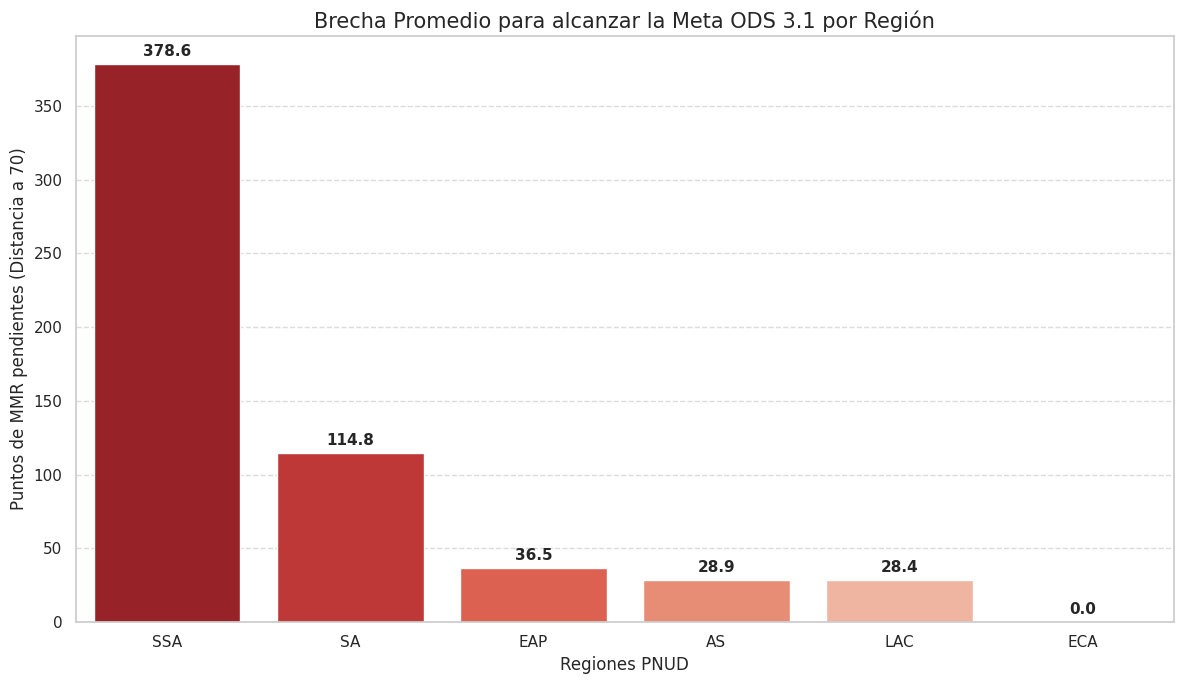

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del gráfico
plt.figure(figsize=(12, 7))

# Crear el gráfico de barras
ax = sns.barplot(x=brecha_regional.index, y=brecha_regional.values, palette='Reds_r')

# Añadir etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# Personalización
plt.title('Brecha Promedio para alcanzar la Meta ODS 3.1 por Región', fontsize=15)
plt.xlabel('Regiones PNUD', fontsize=12)
plt.ylabel('Puntos de MMR pendientes (Distancia a 70)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

La escala del reto en SSA: La barra de África Subsahariana (378.6). Muestra que, en promedio, cada país de esa región debe bajar casi 380 puntos para llegar a la meta. Es una distancia abismal comparada con las demás.

Asia Meridional (SA) en segundo lugar: Con 114.8, es la otra región que claramente no ha logrado romper la barrera de la meta ODS de forma generalizada.

El bloque de los "Cerca de la Meta": EAP, AS y LAC están en un rango muy similar (entre 28 y 36 puntos). Esto sugiere que para América Latina, la meta de 70 es totalmente alcanzable, ya que la brecha promedio es relativamente pequeña.

ECA como referente: La barra en 0.0 es el éxito absoluto. No hay brecha que cerrar.

#Modelo k means

Usaremos solo variables de trayectoria de salud. Esto obliga al algoritmo a mirar "cómo se mueve la enfermedad" y no sobre la economia de los paises (por eso no usamos IDH).

Como ya vimos que hay regiones con brechas enormes y otras con brechas inexistentes, el K-Means nos ayudará a agrupar a los países no por su región, sino por su comportamiento real (mezclando su mortalidad logarítmica, su cambio en la década y la brecha o distancia a la meta).

El primer paso es el Método del Codo. Este gráfico nos dirá matemáticamente cuántos clusters existen realmente en los datos. Aunque nuestra lógica humana dice 3 (Verde, Amarillo, Rojo), el algoritmo podría sugerir algo distinto basándose en la variabilidad.

In [21]:
!pip install scikit-learn-extra

In [22]:
!pip install "numpy<2"

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import adjusted_rand_score

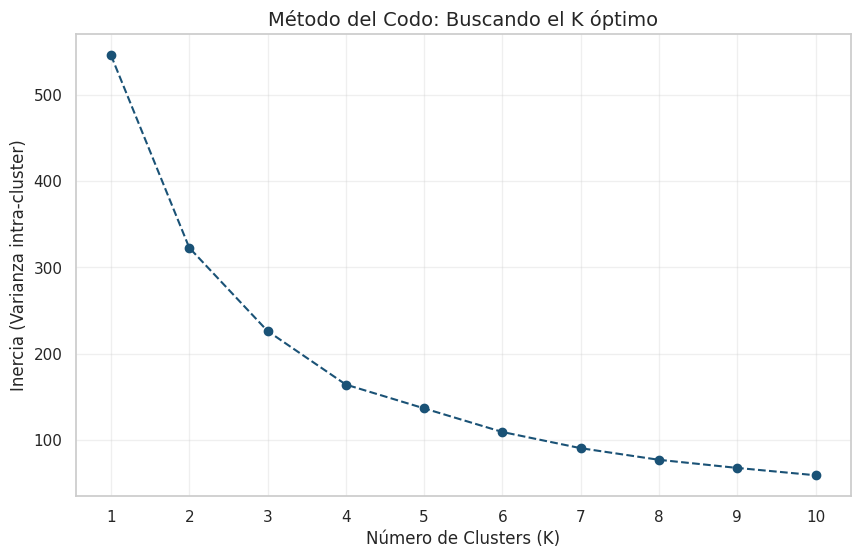

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Preparamos las variables para el modelo
# Usamos: Mortalidad (Log), Cambio de la Década (%) y la Brecha o distancia a la meta
X_final = df_estudio[['log_MMR_2021', 'Cambio_Decada_Pct', 'Brecha_Absoluta']]

# 2. Escalamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# 3. Calculamos la "Inercia" (suma de distancias al cuadrado) para K del 1 al 10
inercia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# 4. Graficamos
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inercia, marker='o', linestyle='--', color='#1a5276')
plt.title('Método del Codo: Buscando el K óptimo', fontsize=14)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Varianza intra-cluster)')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

La caída de la inercia (varianza interna) es muy pronunciada desde $K=1$ hasta $K=3$. Sin embargo, entre $K=3$ y $K=4$ todavía hay un "escalón" significativo de ganancia en precisión.

$K=3$. Matemáticamente es un codo muy claro y permite comparar directamente "K'Means" vs. "Tu Semáforo Manual".

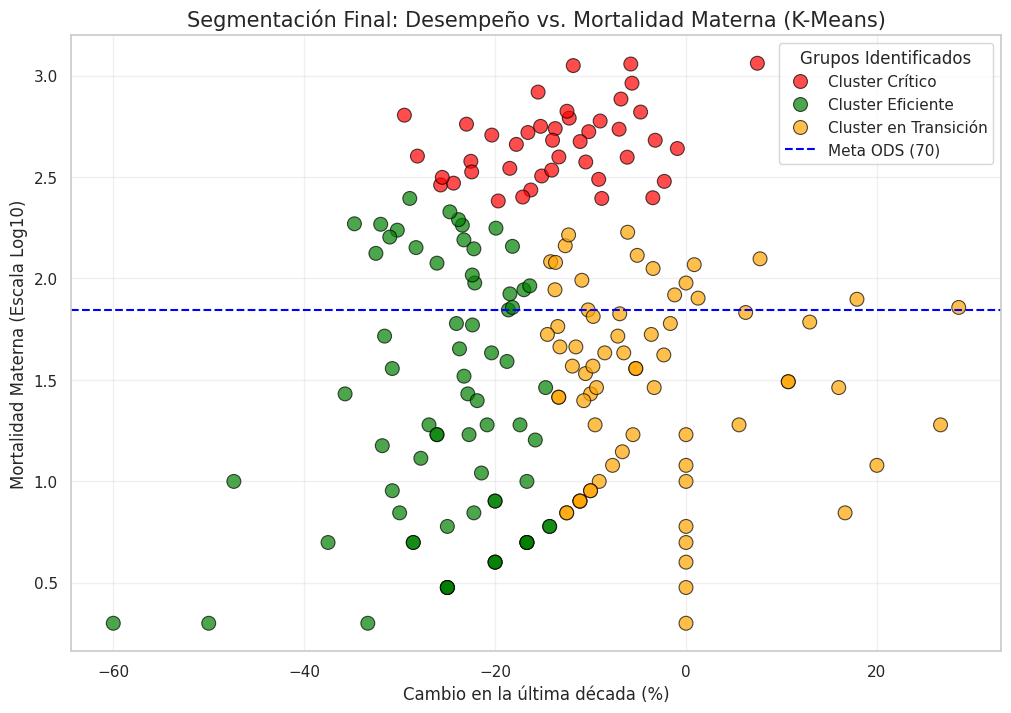

In [25]:
from sklearn.cluster import KMeans

# 1. Aplicamos K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_estudio['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. Renombramos los clusters para que tengan sentido (basado en el promedio de MMR)
# Esto asegura que el cluster con menos muertes sea el '0' y el de más sea el '2'
orden_clusters = df_estudio.groupby('Cluster')['log_MMR_2021'].mean().sort_values().index
mapeo = {orden_clusters[0]: 'Cluster Eficiente',
         orden_clusters[1]: 'Cluster en Transición',
         orden_clusters[2]: 'Cluster Crítico'}
df_estudio['KMeans_Label'] = df_estudio['Cluster'].map(mapeo)

# 3. VISUALIZACIÓN FINAL: Scatter Plot de Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_estudio, x='Cambio_Decada_Pct', y='log_MMR_2021',
                hue='KMeans_Label', palette={'Cluster Eficiente': 'green',
                                             'Cluster en Transición': 'orange',
                                             'Cluster Crítico': 'red'},
                s=100, alpha=0.7, edgecolor='black')

plt.axhline(np.log10(70), color='blue', linestyle='--', label='Meta ODS (70)')
plt.title('Segmentación Final: Desempeño vs. Mortalidad Materna (K-Means)', fontsize=15)
plt.xlabel('Cambio en la última década (%)', fontsize=12)
plt.ylabel('Mortalidad Materna (Escala Log10)', fontsize=12)
plt.legend(title='Grupos Identificados')
plt.grid(True, alpha=0.3)
plt.show()

Este gráfico muestra que la salud materna no es un estado estático, sino un proceso dinámico. Segun las variables cuantitativas que definimos, el algoritmo K-Means no se limitó a seguir la línea azul (Meta ODS de 70), sino que analizó la "velocidad" y la "dirección" de cada país.

1. El Grupo Verde (Cluster Eficiente): El Éxito y la Inercia
Verdes debajo de la meta: Son los países modelo. Ya cumplieron el objetivo de <70 muertes y siguen reduciendo sus cifras o se mantienen estables en niveles muy bajos.

Verdes ARRIBA de la meta (Los "Acelerados"): Estos son los más interesantes. Técnicamente no han llegado a los 70 puntos, pero el algoritmo los puso en verde porque su reducción en la década es muy agresiva (están muy a la izquierda en el Eje X).
El K-Means detecta que estos países están haciendo las cosas tan bien que su comportamiento estadístico se parece más al de un país desarrollado que al de uno en crisis.

2. El Grupo Amarillo (Cluster en Transición): El Riesgo del Estancamiento
Amarillos arriba de la meta: Son países con mortalidad moderada que están bajando sus cifras, pero a un ritmo mucho más lento que los verdes. Están en una "zona de espera".

Amarillos DEBAJO de la meta (Alerta de Retroceso): Estos puntos son críticos . Son países que ya tienen menos de 70 muertes, pero el algoritmo los sacó del grupo verde porque estan pegados al 0 o incluso a la derecha en el eje X. Aunque sus cifras son bajas, se han estancado o están empeorando. El algoritmo nos advierte que, si no actúan, pronto podrían volver a cruzar la línea hacia arriba.

3. El Grupo Rojo (Cluster Crítico): La Crisis Estructural
Este grupo es el más homogéneo y preocupante. Se caracteriza por dos factores:

Mortalidad persistentemente alta: Todos están muy por encima de la línea azul (escala logarítmica de 2.0 a 3.0, que equivale a entre 100 y 1000 muertes).
Dificultad de cambio: La mayoría están agrupados cerca del centro del Eje X. Esto significa que, a pesar de tener cifras altísimas, su porcentaje de mejora en la última década ha sido insuficiente para sacarlos de la zona de peligro.

Representan el núcleo de la desigualdad global donde las brechas (que calculamos en el Objetivo 2) son más profundas.

In [26]:
# 1. Seleccionamos las columnas clave para el reporte
columnas_reporte = [
    'Country',
    'UNDP Developeing Regions',
    col_2021,
    'Cambio_Decada_Pct',
    'KMeans_Label'
]

# 2. Creamos el DataFrame final ordenado
# Primero por Cluster (para agruparlos) y luego por MMR de mayor a menor
tabla_paises_final = df_estudio[columnas_reporte].sort_values(
    by=['KMeans_Label', col_2021],
    ascending=[True, False]
)

# 3. Renombramos columnas
tabla_paises_final.columns = [
    'País',
    'Región PNUD',
    'MMR 2021',
    '% Cambio Década',
    'Segmento (K-Means)'
]

# 4. Mostrar los primeros 50 registros
print("--- LISTADO MAESTRO DE CLASIFICACIÓN POR PAÍS ---")
print(tabla_paises_final.to_string(index=False))


--- LISTADO MAESTRO DE CLASIFICACIÓN POR PAÍS ---
                                País Región PNUD  MMR 2021  % Cambio Década    Segmento (K-Means)
                         South Sudan         SSA    1150.0         7.476636       Cluster Crítico
                                Chad         SSA    1140.0        -5.785124       Cluster Crítico
                        Sierra Leone         SSA    1120.0       -11.811024       Cluster Crítico
                             Nigeria         SSA     917.0        -5.658436       Cluster Crítico
            Central African Republic         SSA     829.0       -15.494393       Cluster Crítico
                          Mauritania         SSA     766.0        -6.812652       Cluster Crítico
                       Guinea-Bissau         SSA     667.0       -12.467192       Cluster Crítico
                             Liberia         SSA     661.0        -4.755043       Cluster Crítico
                         Afghanistan          SA     638.0       -29

1. El Cluster Eficiente (Los "Overachievers")
Lo que hace especial a este grupo no es solo que tengan un MMR bajo, sino su capacidad de transformación.

Casos de éxito extremo: Países como Kazajistán (-47.4%), Bielorrusia (-60%) y Noruega (-50%) muestran que es posible reducir la mortalidad a la mitad en solo una década.

La "Vía Rápida" (Verdes arriba de 70): Nota a India (133.0) y Ruanda (248.0). Aunque sus tasas son altas, el algoritmo los premia con el color verde porque su reducción (cercana al -30%) es tan constante que su "perfil de salud" ya no es de crisis, sino de mejora acelerada.

2. El Cluster en Transición (La Alerta de Estancamiento)

El Retroceso Desarrollado: Estados Unidos (MMR 19.0, +26.7% de cambio) o Alemania (MMR 7.0, +16.7%). El K-Means los sacó del grupo "Eficiente" y los puso en "Transición" porque, aunque tienen pocas muertes, su tendencia es al alza. Esto es una crítica directa a los sistemas de salud en países ricos.

La Trampa de la Meta: Países como Colombia (83.0) o República Dominicana (95.0) están cerca de la meta de 70, pero su cambio es del -1.2% o 0.0%. El algoritmo advierte que, a ese ritmo de estancamiento, nunca cruzarán al grupo verde.

3. El Cluster Crítico (La Emergencia Estructural)
Aquí la estadística confirma la tragedia geográfica.

El Abismo de SSA: Casi toda la lista roja pertenece a África Subsahariana. Lo más grave es que países como Sudán del Sur (+7.5%) no solo tienen las tasas más altas del mundo (1150), sino que están empeorando.

La Excepción de Haití: Es el único país de LAC que cae en este cluster crítico con un MMR de 480 y una mejora casi inexistente (-3.2%).

**El Salvador: Cluster en Transición**
A pesar de tener una tasa de mortalidad materna relativamente baja, el modelo no lo clasifica como "Eficiente". )MMR 2021: 46.0. y % Cambio Década: -13.2%).

 El Salvador ya se encuentra por debajo de la meta ODS de 70. Sin embargo, su ritmo de reducción del 13.2% en la última década es considerado por el algoritmo como un avance "moderado" o en transición en comparación con los líderes globales que están reduciendo sus cifras a ritmos del 30% o 40%. ES UN ERROR DEL MODELO? Al estar en este cluster, el modelo sugiere que el país ha entrado en una zona de posible estancamiento donde el progreso es lento.

**México: Cluster Eficiente**
México logra entrar en el grupo de alto desempeño, validando su estrategia de la última década. (MMR 2021: 33.0. Y % Cambio Década: -23.3%)

México no solo tiene una cifra menor que la de El Salvador, sino que su velocidad de mejora ha sido casi el doble (-23.3% vs -13.2%). El algoritmo lo identifica como un país con un comportamiento "Eficiente" porque combina una baja mortalidad con una tendencia de reducción robusta y constante.

**República Dominicana: Cluster en Transición**
A diferencia de México o El Salvador, República Dominicana presenta un perfil donde el progreso parece haberse detenido por completo en la última década registrada. MR 2021: 95.0 (Todavía por encima de la meta de 70). % Cambio Década (2011-2021): 0.0%.

Este es el dato más revelador. Un cambio del 0.0% significa que, estadísticamente, el país tiene la misma tasa de mortalidad hoy que hace diez años. El algoritmo lo asigna al Cluster en Transición (Amarillo). Aunque no tiene las tasas críticas de África (Rojo), su falta de movimiento lo aleja del grupo de éxito.

In [27]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df_estudio['Cluster'])
print(f"Coeficiente de Silueta: {score:.3f}")

Coeficiente de Silueta: 0.347


In [28]:
# Validamos si las diferencias de medias entre clusters son estadísticamente significativas
validacion_medias = df_estudio.groupby('KMeans_Label')[['log_MMR_2021', 'Cambio_Decada_Pct', 'Brecha_Absoluta']].mean()
print(validacion_medias)

                       log_MMR_2021  Cambio_Decada_Pct  Brecha_Absoluta
KMeans_Label                                                           
Cluster Crítico            2.663963         -13.384396       436.833333
Cluster Eficiente          1.354617         -24.853461        22.788732
Cluster en Transición      1.479848          -3.484907         9.826087


Si el score es > 0.5: estructura de clusters sólida. Los países están claramente diferenciados.

Si el score está entre 0.25 y 0.50: Hay una estructura razonable, aunque algunos países podrían estar cerca de la frontera de otro grupo.

Un valor de 0.347 indica que existe una estructura de clusters razonable, pero con traslape en las fronteras.

La realidad de la mortalidad materna no tiene cortes "quirúrgicos". El traslape ocurre porque hay países en la frontera que comparten características de dos grupos.

El coeficiente de 0.347 valida la existencia de tres perfiles globales distintos, reconociendo la complejidad de los datos donde algunos países actúan como puentes de transición entre el éxito y la crisis

# **Porque No k'means?Porque si?**

El Sesgo y la Transformación Logarítmica
Los datos de mortalidad materna están muy sesgados a la derecha (pocos países con muchísimas muertes, como Sudán del Sur).

El K-Means usa la media como centro, y la media es muy sensible a los valores extremos (outliers). Un solo país con 1150 muertes "jala" el centro del cluster rojo hacia arriba.

Nuestra solución: Por eso aplicamos log_MMR_2021. Al usar logaritmos, "comprimimos" la distancia entre los extremos. Esto redujo el sesgo y permitió que el K-Means funcionara mucho mejor de lo que lo habría hecho con los datos originales.

Los valores extremos (como los de África Subsahariana) son importantes. No son errores de medición; son la realidad del problema.

El K-Means, al ser sensible a esos valores, logra separar el Cluster Crítico con mucha fuerza.

Si usáramos un modelo demasiado robusto (como K-Medoids), podríamos terminar ignorando la gravedad de los países en crisis extrema al "normalizarlos" demasiado.

#**¿Cómo validamos si el sesgo afectó demasiado?**
Comparando los centros del K-Means con las medianas de cada cluster. Si son parecidas, el sesgo está controlado.

In [29]:
# 1. Calculamos Media y Mediana para las variables clave por cada Cluster
comparativa_robusta = df_estudio.groupby('KMeans_Label').agg({
    'log_MMR_2021': ['mean', 'median'],
    'Cambio_Decada_Pct': ['mean', 'median'],
    'Brecha_Absoluta': ['mean', 'median']
})

# 2. Calculamos la diferencia porcentual para ver qué tanto "pesa" el sesgo
# Una diferencia pequeña (<10-15%) indica que el K-Means es confiable
print("--- AUDITORÍA DE SESGO: MEDIA vs. MEDIANA ---")
print(comparativa_robusta)

--- AUDITORÍA DE SESGO: MEDIA vs. MEDIANA ---
                      log_MMR_2021           Cambio_Decada_Pct             \
                              mean    median              mean     median   
KMeans_Label                                                                
Cluster Crítico           2.663963  2.667863        -13.384396 -13.509782   
Cluster Eficiente         1.354617  1.278754        -24.853461 -23.267327   
Cluster en Transición     1.479848  1.556303         -3.484907  -6.521739   

                      Brecha_Absoluta         
                                 mean median  
KMeans_Label                                  
Cluster Crítico            436.833333  395.5  
Cluster Eficiente           22.788732    0.0  
Cluster en Transición        9.826087    0.0  


**El éxito de la transformación logarítmica (log_MMR_2021)**

Media: 2.663 vs. Mediana: 2.667.

La diferencia es mínima (menos del 0.2%). Esto demuestra que, en escala logarítmica, el grupo más extremo del mundo está perfectamente balanceado. Los países con 1,000 muertes ya no "arrastran" el promedio de forma injusta; el algoritmo está viendo una estructura real, no solo ruido de outliers.

**La naturaleza de la "Brecha Absoluta"**

En el Cluster Crítico, la media de la brecha es 436, pero la mediana es 395.
Aquí sí hay un ligero sesgo a la derecha. Países como Sudán del Sur (con brechas >1000) están elevando el promedio del grupo.

Esto es una característica del fenómeno.Esto justifica por qué el cluster se llama "Crítico": porque el promedio es empujado por crisis humanitarias extremas que no pueden ser ignoradas por una mediana "cómoda".

**El comportamiento del Cluster Eficiente y de Transición**
En ambos, la mediana de la Brecha Absoluta es 0.0.

Esto valida matemáticamente lo que vimos en el gráfico: la mayoría de los países en estos grupos ya alcanzaron la meta de 70 (por eso su brecha es 0). El hecho de que la media sea 22.7 o 9.8 es lo que captura a esos países que mencionamos antes (los que están "arriba" de la meta pero el algoritmo clasificó ahí por su buena velocidad o estancamiento).

#K-Medoids (k'Medianas)

In [30]:
X_final = df_estudio[['log_MMR_2021', 'Cambio_Decada_Pct', 'Brecha_Absoluta']]
X_scaled = scaler.fit_transform(X_final)

# ejecutamos el K-Medoids
kmedoids = KMedoids(n_clusters=3, random_state=42, metric='manhattan')
df_estudio['Cluster_Medoid'] = kmedoids.fit_predict(X_scaled)

# Mapeo de nombres para comparar
centros_med = df_estudio.groupby('Cluster_Medoid')['log_MMR_2021'].mean().sort_values().index
mapeo_med = {centros_med[0]: 'Medoid Eficiente',
             centros_med[1]: 'Medoid Transición',
             centros_med[2]: 'Medoid Crítico'}
df_estudio['KMedoids_Label'] = df_estudio['Cluster_Medoid'].map(mapeo_med)

# Generamos la matriz de comparación
comparativa = pd.crosstab(df_estudio['KMeans_Label'], df_estudio['KMedoids_Label'])
print("--- COMPARACIÓN K-MEANS vs K-MEDOIDS ---")
print(comparativa)

# Calculamos la similitud (ARI)
ari = adjusted_rand_score(df_estudio['KMeans_Label'], df_estudio['Cluster_Medoid'])
print(f"\nÍndice de Rand Ajustado: {ari:.4f}")

--- COMPARACIÓN K-MEANS vs K-MEDOIDS ---
KMedoids_Label         Medoid Crítico  Medoid Eficiente  Medoid Transición
KMeans_Label                                                              
Cluster Crítico                    42                 0                  0
Cluster Eficiente                   0                 9                 62
Cluster en Transición               0                69                  0

Índice de Rand Ajustado: 0.8422


**El Cluster Crítico **
Coincidencia: 42 de 42 países.
 No importa si usas la media o la mediana; los países en situación crítica están tan alejados del resto del mundo que ningún cambio de algoritmo los mueve. Esto valida que la crisis en esos países (principalmente de África Subsahariana) es una realidad estadística absoluta.

**Eficiente vs. Transición**

62 países que el K-Means decía que eran "Eficientes" pasaron a ser "Medoid Transición". 69 países que el K-Means decía que eran "Transición" pasaron a ser "Medoid Eficiente".

Esto sucede por la métrica de distancia. El K-Means usa la distancia Euclidiana (línea recta al cuadrado), que castiga mucho los valores alejados. El K-Medoids usa Manhattan (distancia en bloques), que es más "permisiva".

La robustez del modelo fue evaluada mediante un análisis comparativo entre K-Means y K-Medoids. El Índice de Rand Ajustado (0.8422) confirma una alta estabilidad en la estructura de los datos. Mientras que el segmento 'Crítico' se mantuvo inalterado (100% de coincidencia), se observó una reconfiguración en los grupos 'Eficiente' y 'Transición'. Esto indica que, para los países con mortalidad media-baja, la clasificación es sensible a la métrica de centralidad (media vs. mediana), lo que refuerza la necesidad de monitorear no solo la tasa absoluta, sino la velocidad de cambio decada

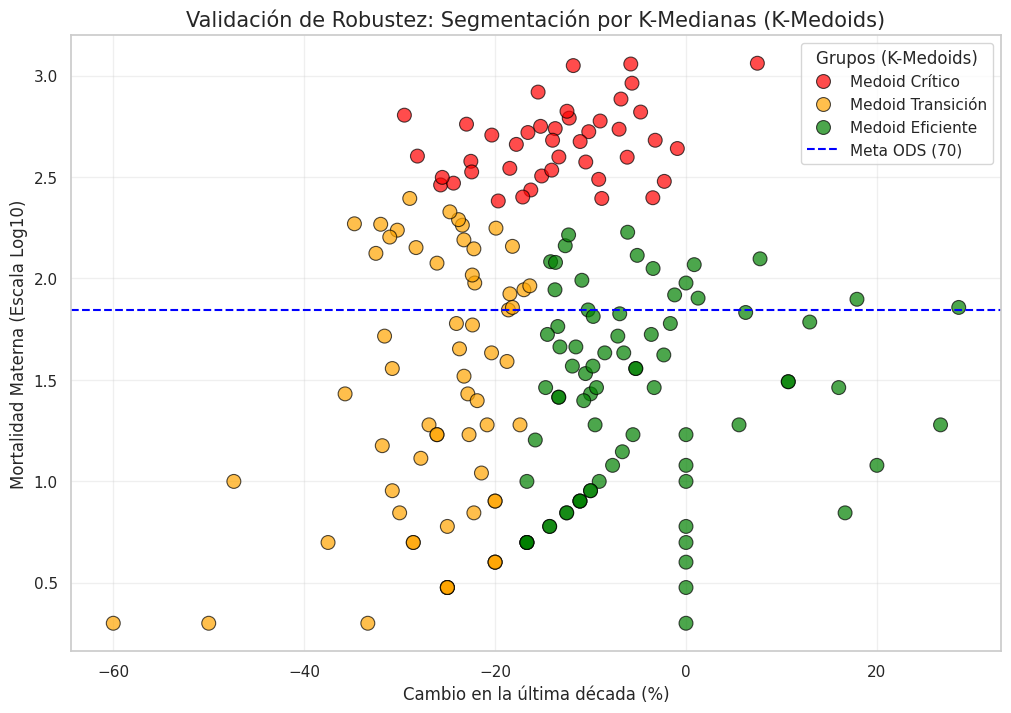

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos el gráfico de dispersión para K-Medoids
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_estudio, x='Cambio_Decada_Pct', y='log_MMR_2021',
                hue='KMedoids_Label',
                palette={'Medoid Eficiente': 'green',
                         'Medoid Transición': 'orange',
                         'Medoid Crítico': 'red'},
                s=100, alpha=0.7, edgecolor='black')

# 2. Añadimos la línea de la Meta ODS (70)
plt.axhline(np.log10(70), color='blue', linestyle='--', label='Meta ODS (70)')

plt.title('Validación de Robustez: Segmentación por K-Medianas (K-Medoids)', fontsize=15)
plt.xlabel('Cambio en la última década (%)', fontsize=12)
plt.ylabel('Mortalidad Materna (Escala Log10)', fontsize=12)
plt.legend(title='Grupos (K-Medoids)')
plt.grid(True, alpha=0.3)

plt.show()

Cluster Eficiente (Verde): Ahora el algoritmo ha decidido que el "éxito" está en el lado derecho del gráfico (países que están cerca del 0% de cambio o incluso positivos, pero con mortalidades extremadamente bajas). Son países que ya llegaron al límite de lo que pueden mejorar y se mantienen estables en la excelencia.

Cluster Transición (Amarillo): Ahora el grupo amarillo se movió a la izquierda. El K-Medoids está agrupando aquí a los países que están haciendo un esfuerzo masivo de reducción (entre -20% y -60%).

El Cluster Crítico (Rojo) Se mantiene como una mancha aislada en la parte superior. No importa el modelo, estos países están en una liga de riesgo propia.

In [32]:

col_mmr_real = [c for c in df_estudio.columns if 'MMR' in c and '2021' in c][0]
print(f"Usando la columna: {col_mmr_real}")


columnas_finales = [
    'Country',
    'UNDP Developeing Regions',
    col_mmr_real,
    'Cambio_Decada_Pct',
    'KMeans_Label',
    'KMedoids_Label'
]

# Creamos la tabla comparativa
tabla_comparativa = df_estudio[columnas_finales].sort_values(
    by=['KMedoids_Label', col_mmr_real],
    ascending=[True, False]
)

# Renombramos para el reporte final
tabla_comparativa.columns = [
    'País', 'Región', 'MMR 2021', '% Cambio', 'K-Means', 'K-Medoids'
]

# Mostramos los resultados
print("--- LISTADO MAESTRO DE VALIDACIÓN CRUZADA ---")
print(tabla_comparativa.to_string(index=False))

Usando la columna: log_MMR_2021
--- LISTADO MAESTRO DE VALIDACIÓN CRUZADA ---
                                País Región  MMR 2021   % Cambio               K-Means         K-Medoids
                         South Sudan    SSA  3.060698   7.476636       Cluster Crítico    Medoid Crítico
                                Chad    SSA  3.056905  -5.785124       Cluster Crítico    Medoid Crítico
                        Sierra Leone    SSA  3.049218 -11.811024       Cluster Crítico    Medoid Crítico
                             Nigeria    SSA  2.962369  -5.658436       Cluster Crítico    Medoid Crítico
            Central African Republic    SSA  2.918555 -15.494393       Cluster Crítico    Medoid Crítico
                          Mauritania    SSA  2.884229  -6.812652       Cluster Crítico    Medoid Crítico
                       Guinea-Bissau    SSA  2.824126 -12.467192       Cluster Crítico    Medoid Crítico
                             Liberia    SSA  2.820201  -4.755043       Cluster Crí

**El Salvador y México: **
En K-Means: Ambos estaban en "Transición" (Amarillo) o "Eficiente" (Verde) dependiendo de su distancia al promedio.
En K-Medoids: Ambos han sido agrupados en el Medoid Transición (que en este modelo representa a los países con altas tasas de reducción)

El K-Medoids reconoce que el valor real de México (-23.2%) y El Salvador (-13.2%) no es solo su cifra de mortalidad, sino que son parte de un grupo global que está "empujando" la cifra hacia abajo con fuerza.

2. El caso de Rep. Dominicana
En K-Means: Era "Cluster en Transición".
En K-Medoids: Ahora es Medoid Eficiente
No es porque haya mejorado (sigue en 0.0% de cambio), sino porque el K-Medoids agrupó en el cluster "Eficiente" a todos los países que tienen mortalidades bajas/medias y que ya no se mueven mucho. El modelo dice: "República Dominicana se comporta como un país desarrollado estancado, no como un país en crisis".

#**Cual usaremos?**

Se concluye que el modelo K-Means con transformación logarítmica es el más adecuado para representar la magnitud de las brechas globales, mientras que el modelo K-Medoids actúa como una herramienta de validación de robustez (ARI: 0.8422) que permite identificar patrones de comportamiento y trayectorias de mejora, independientemente de los valores atípicos.

#Otros graficos

/tmp/ipykernel_6026/1494178210.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_estudio, x=col_2021, y='UNDP Developeing Regions',


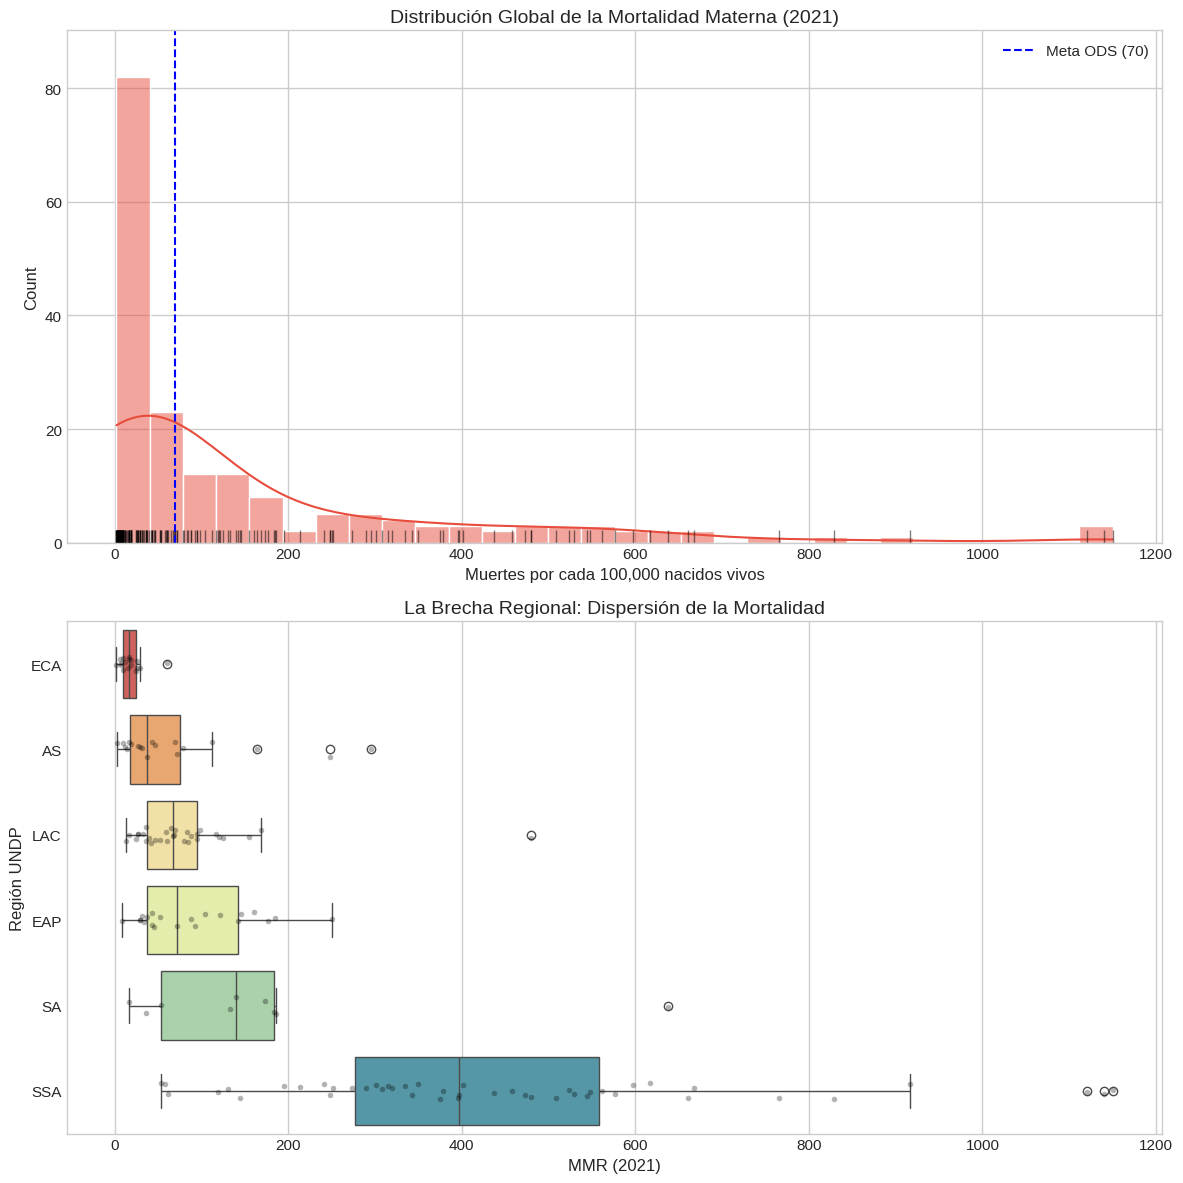

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estética profesional
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# 1. HISTOGRAMA: La concentración de la tragedia
sns.histplot(df_estudio[col_2021], bins=30, kde=True, ax=ax1, color='#e74c3c')
sns.rugplot(df_estudio[col_2021], ax=ax1, color='black', alpha=0.5) # Rayitas individuales por país
ax1.axvline(70, color='blue', linestyle='--', label='Meta ODS (70)')
ax1.set_title('Distribución Global de la Mortalidad Materna (2021)', fontsize=14)
ax1.set_xlabel('Muertes por cada 100,000 nacidos vivos')
ax1.legend()

# 2. BOXPLOT: Desigualdad por Regiones (Datos Crudos)
# Ordenamos las regiones por la mediana de mortalidad
order = df_estudio.groupby('UNDP Developeing Regions')[col_2021].median().sort_values().index

sns.boxplot(data=df_estudio, x=col_2021, y='UNDP Developeing Regions',
            order=order, palette='Spectral', ax=ax2)
sns.stripplot(data=df_estudio, x=col_2021, y='UNDP Developeing Regions',
              order=order, color='black', size=4, alpha=0.3, ax=ax2) # Puntos reales
ax2.set_title('La Brecha Regional: Dispersión de la Mortalidad', fontsize=14)
ax2.set_xlabel('MMR (2021)')
ax2.set_ylabel('Región UNDP')

plt.tight_layout()
plt.show()

# DBSCAN & HDBSCAN

In [34]:

!pip install hdbscan

from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
[x for x in globals().keys() if x.startswith('df')]

for nombre in [x for x in globals().keys() if x.startswith('df')]:
    try:
        print(f"\nDataFrame: {nombre}")
        print(globals()[nombre].columns.tolist())
    except:
        pass


DataFrame: df
['ISO3', 'Country', 'Continent', 'Hemisphere', 'Human Development Groups', 'UNDP Developeing Regions', 'HDI Rank (2021)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1990)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1991)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1992)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1993)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1994)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1995)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1996)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1997)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1998)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1999)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (2000)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (2001)', 'Maternal Mortality Ratio (deaths per 100,000 l

In [36]:
# Variables del modelo
X_final = df_estudio[['log_MMR_2021', 'Cambio_Decada_Pct', 'Brecha_Absoluta']]

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

In [37]:
dbscan = DBSCAN(eps=0.9, min_samples=5)
df_estudio['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Ver resultados
print("Clusters encontrados por DBSCAN:", sorted(df_estudio['Cluster_DBSCAN'].unique()))
print(df_estudio['Cluster_DBSCAN'].value_counts().sort_index())

Clusters encontrados por DBSCAN: [-1, 0]
Cluster_DBSCAN
-1      5
 0    177
Name: count, dtype: int64


In [38]:
labels_db = df_estudio['Cluster_DBSCAN'].values

# Número de clusters reales (sin contar ruido)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = list(labels_db).count(-1)

print(f"Número de clusters reales (DBSCAN): {n_clusters_db}")
print(f"Número de países clasificados como ruido: {n_noise_db}")

if n_clusters_db >= 2:
    mask = labels_db != -1
    score_db = silhouette_score(X_scaled[mask], labels_db[mask])
    print(f"Silhouette DBSCAN (sin ruido): {score_db:.3f}")
else:
    print("DBSCAN no generó suficientes clusters para calcular silhouette.")

Número de clusters reales (DBSCAN): 1
Número de países clasificados como ruido: 5
DBSCAN no generó suficientes clusters para calcular silhouette.


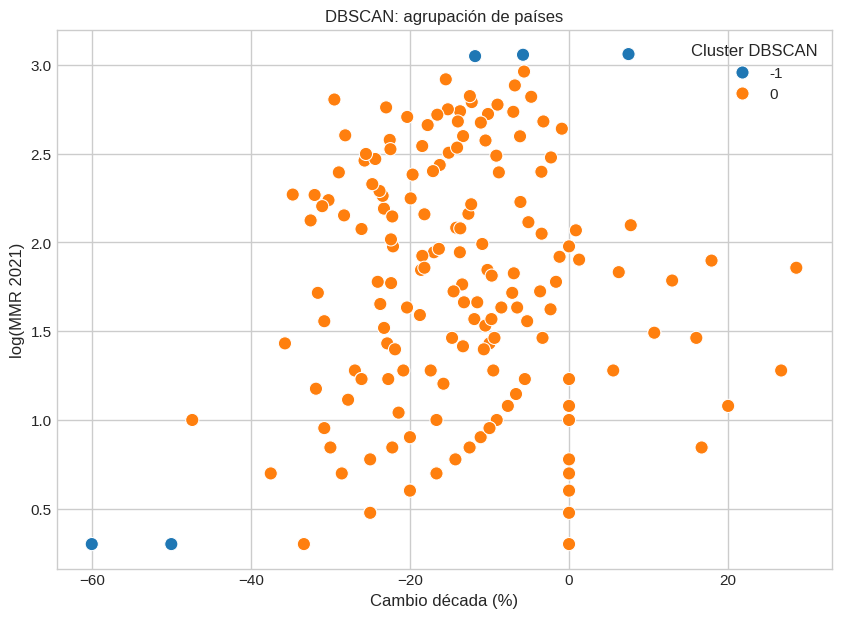

In [39]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_estudio,
    x='Cambio_Decada_Pct',
    y='log_MMR_2021',
    hue='Cluster_DBSCAN',
    palette='tab10',
    s=90
)

plt.title('DBSCAN: agrupación de países')
plt.xlabel('Cambio década (%)')
plt.ylabel('log(MMR 2021)')
plt.legend(title='Cluster DBSCAN')
plt.show()

In [40]:
columnas_dbscan = [
    'Country',
    'UNDP Developeing Regions',
    'log_MMR_2021',
    'Cambio_Decada_Pct',
    'Brecha_Absoluta',
    'Cluster_DBSCAN'
]

df_estudio[columnas_dbscan].sort_values('Cluster_DBSCAN').head(30)

,Country,UNDP Developeing Regions,log_MMR_2021,Cambio_Decada_Pct,Brecha_Absoluta,Cluster_DBSCAN
130,Norway,NaN,0.301030,-50.000000,0.0,-1
20,Belarus,ECA,0.301030,-60.000000,0.0,-1
160,South Sudan,SSA,3.060698,7.476636,1080.0,-1
155,Sierra Leone,SSA,3.049218,-11.811024,1050.0,-1
169,Chad,SSA,3.056905,-5.785124,1070.0,-1
136,Panama,LAC,1.716003,-31.578947,0.0,0
123,Malawi,SSA,2.542825,-18.457944,279.0,0
141,Poland,NaN,0.301030,-33.333333,0.0,0
124,Malaysia,EAP,1.462398,-3.333333,0.0,0
125,Namibia,SSA,2.290035,-23.828125,125.0,0


In [41]:
hdb = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=4)
df_estudio['Cluster_HDBSCAN'] = hdb.fit_predict(X_scaled)

print("Clusters encontrados por HDBSCAN:", sorted(df_estudio['Cluster_HDBSCAN'].unique()))
print(df_estudio['Cluster_HDBSCAN'].value_counts().sort_index())


Clusters encontrados por HDBSCAN: [-1, 0, 1]
Cluster_HDBSCAN
-1     71
 0      8
 1    103
Name: count, dtype: int64


In [42]:
labels_hdb = df_estudio['Cluster_HDBSCAN'].values

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise_hdb = list(labels_hdb).count(-1)

print(f"Número de clusters reales (HDBSCAN): {n_clusters_hdb}")
print(f"Número de países clasificados como ruido: {n_noise_hdb}")

if n_clusters_hdb >= 2:
    mask = labels_hdb != -1
    score_hdb = silhouette_score(X_scaled[mask], labels_hdb[mask])
    print(f"Silhouette HDBSCAN (sin ruido): {score_hdb:.3f}")
else:
    print("HDBSCAN no generó suficientes clusters para calcular silhouette.")

Número de clusters reales (HDBSCAN): 2
Número de países clasificados como ruido: 71
Silhouette HDBSCAN (sin ruido): 0.362


In [43]:
df_estudio['Prob_HDBSCAN'] = hdb.probabilities_

df_estudio[['Country', 'Cluster_HDBSCAN', 'Prob_HDBSCAN']].sort_values(
    'Prob_HDBSCAN',
    ascending=False
).head(20)

,Country,Cluster_HDBSCAN,Prob_HDBSCAN
165,Sweden,1,1.0
51,Egypt,1,1.0
89,Kenya,0,1.0
156,El Salvador,1,1.0
87,Japan,1,1.0
86,Jordan,1,1.0
85,Jamaica,1,1.0
82,Iceland,1,1.0
76,Hungary,1,1.0
162,Suriname,1,1.0


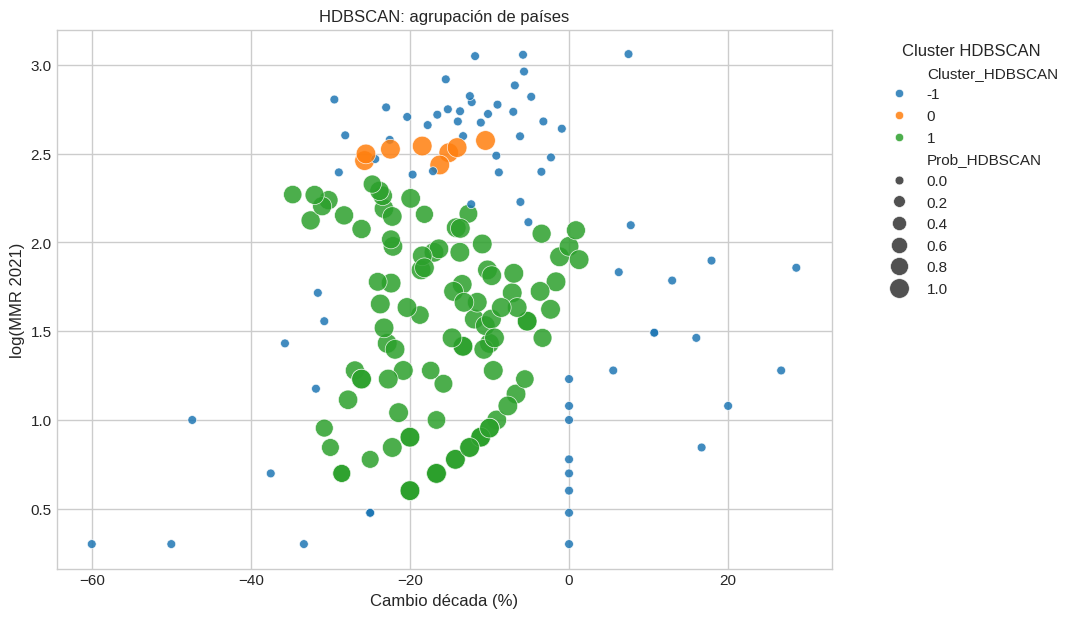

In [44]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_estudio,
    x='Cambio_Decada_Pct',
    y='log_MMR_2021',
    hue='Cluster_HDBSCAN',
    size='Prob_HDBSCAN',
    sizes=(40, 200),
    palette='tab10',
    alpha=0.85
)

plt.title('HDBSCAN: agrupación de países')
plt.xlabel('Cambio década (%)')
plt.ylabel('log(MMR 2021)')
plt.legend(title='Cluster HDBSCAN', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [45]:
columnas_hdbscan = [
    'Country',
    'UNDP Developeing Regions',
    'log_MMR_2021',
    'Cambio_Decada_Pct',
    'Brecha_Absoluta',
    'Cluster_HDBSCAN',
    'Prob_HDBSCAN'
]

df_estudio[columnas_hdbscan].sort_values(
    ['Cluster_HDBSCAN', 'Prob_HDBSCAN'],
    ascending=[True, False]
).head(40)

,Country,UNDP Developeing Regions,log_MMR_2021,Cambio_Decada_Pct,Brecha_Absoluta,Cluster_HDBSCAN,Prob_HDBSCAN
0,Afghanistan,SA,2.804821,-29.502762,568.0,-1,0.0
1,Angola,SSA,2.382017,-19.666667,171.0,-1,0.0
2,Albania,ECA,1.176091,-31.818182,0.0,-1,0.0
4,United Arab Emirates,AS,0.477121,-25.000000,0.0,-1,0.0
8,Australia,NaN,0.778151,0.000000,0.0,-1,0.0
9,Austria,NaN,0.698970,0.000000,0.0,-1,0.0
11,Burundi,SSA,2.738781,-13.700787,478.0,-1,0.0
13,Benin,SSA,2.598791,-13.318777,327.0,-1,0.0
19,Bosnia and Herzegovina,ECA,1.000000,0.000000,0.0,-1,0.0
20,Belarus,ECA,0.301030,-60.000000,0.0,-1,0.0


In [46]:
resumen_hdb = df_estudio.groupby('Cluster_HDBSCAN')[[
    'log_MMR_2021',
    'Cambio_Decada_Pct',
    'Brecha_Absoluta'
]].mean().sort_values('log_MMR_2021')

print(resumen_hdb)

                 log_MMR_2021  Cambio_Decada_Pct  Brecha_Absoluta
Cluster_HDBSCAN                                                  
 1                   1.498857         -16.255174        17.466019
-1                   1.911479         -10.490379       236.704225
 0                   2.509556         -18.512385       254.750000


In [47]:
# EJEMPLO: revisar primero el resumen_hdb para decidir el mapeo correcto
mapa_hdb = {
    0: 'Eficiente',
    1: 'Transición',
    2: 'Crítico',
    -1: 'Atípico'
}

df_estudio['Semaforo_HDBSCAN'] = df_estudio['Cluster_HDBSCAN'].map(mapa_hdb)

df_estudio[['Country', 'Cluster_HDBSCAN', 'Semaforo_HDBSCAN']].head(20)

,Country,Cluster_HDBSCAN,Semaforo_HDBSCAN
0,Afghanistan,-1,Atípico
1,Angola,-1,Atípico
2,Albania,-1,Atípico
4,United Arab Emirates,-1,Atípico
5,Argentina,1,Transición
6,Armenia,1,Transición
7,Antigua and Barbuda,1,Transición
8,Australia,-1,Atípico
9,Austria,-1,Atípico
10,Azerbaijan,1,Transición


In [48]:
#Prueba

hdb = hdbscan.HDBSCAN(min_cluster_size=12, min_samples=3)

resumen_hdb = df_estudio.groupby('Cluster_HDBSCAN')[[
    'log_MMR_2021',
    'Cambio_Decada_Pct',
    'Brecha_Absoluta'
]].mean().sort_values('log_MMR_2021')

print(resumen_hdb)

df_estudio[['Country', 'Cluster_HDBSCAN', 'Prob_HDBSCAN']].sort_values(
    ['Cluster_HDBSCAN', 'Prob_HDBSCAN'],
    ascending=[True, False]
)

mapa_hdb = {
    1: 'Eficiente',
    0: 'Crítico',
    -1: 'Atípico/Frontera'
}

df_estudio['Semaforo_HDBSCAN'] = df_estudio['Cluster_HDBSCAN'].map(mapa_hdb)

df_estudio[['Country', 'Cluster_HDBSCAN', 'Semaforo_HDBSCAN']].head(20)

                 log_MMR_2021  Cambio_Decada_Pct  Brecha_Absoluta
Cluster_HDBSCAN                                                  
 1                   1.498857         -16.255174        17.466019
-1                   1.911479         -10.490379       236.704225
 0                   2.509556         -18.512385       254.750000


,Country,Cluster_HDBSCAN,Semaforo_HDBSCAN
0,Afghanistan,-1,Atípico/Frontera
1,Angola,-1,Atípico/Frontera
2,Albania,-1,Atípico/Frontera
4,United Arab Emirates,-1,Atípico/Frontera
5,Argentina,1,Eficiente
6,Armenia,1,Eficiente
7,Antigua and Barbuda,1,Eficiente
8,Australia,-1,Atípico/Frontera
9,Austria,-1,Atípico/Frontera
10,Azerbaijan,1,Eficiente


In [49]:
#Prueba2

hdb = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=3)

resumen_hdb = df_estudio.groupby('Cluster_HDBSCAN')[[
    'log_MMR_2021',
    'Cambio_Decada_Pct',
    'Brecha_Absoluta'
]].mean().sort_values('log_MMR_2021')

print(resumen_hdb)

df_estudio[['Country', 'Cluster_HDBSCAN', 'Prob_HDBSCAN']].sort_values(
    ['Cluster_HDBSCAN', 'Prob_HDBSCAN'],
    ascending=[True, False]
)

mapa_hdb = {
    1: 'Eficiente',
    0: 'Crítico',
    -1: 'Atípico/Frontera'
}

df_estudio['Semaforo_HDBSCAN'] = df_estudio['Cluster_HDBSCAN'].map(mapa_hdb)

df_estudio[['Country', 'Cluster_HDBSCAN', 'Semaforo_HDBSCAN']].head(20)

                 log_MMR_2021  Cambio_Decada_Pct  Brecha_Absoluta
Cluster_HDBSCAN                                                  
 1                   1.498857         -16.255174        17.466019
-1                   1.911479         -10.490379       236.704225
 0                   2.509556         -18.512385       254.750000


,Country,Cluster_HDBSCAN,Semaforo_HDBSCAN
0,Afghanistan,-1,Atípico/Frontera
1,Angola,-1,Atípico/Frontera
2,Albania,-1,Atípico/Frontera
4,United Arab Emirates,-1,Atípico/Frontera
5,Argentina,1,Eficiente
6,Armenia,1,Eficiente
7,Antigua and Barbuda,1,Eficiente
8,Australia,-1,Atípico/Frontera
9,Austria,-1,Atípico/Frontera
10,Azerbaijan,1,Eficiente


In [50]:
#Prueba3

print("=== DBSCAN ===")
print(pd.Series(labels_db).value_counts().sort_index())

print("\n=== HDBSCAN ===")
print(pd.Series(labels_hdb).value_counts().sort_index())

print("\n=== Resumen HDBSCAN ===")
print(
    df_estudio.groupby('Cluster_HDBSCAN')[[
        'log_MMR_2021',
        'Cambio_Decada_Pct',
        'Brecha_Absoluta'
    ]].mean().sort_values('log_MMR_2021')
)

print("\n=== Países por cluster HDBSCAN ===")
print(
    df_estudio[['Country', 'Cluster_HDBSCAN', 'Prob_HDBSCAN']]
    .sort_values(['Cluster_HDBSCAN', 'Prob_HDBSCAN'], ascending=[True, False])
    .head(30)
)

=== DBSCAN ===
-1      5
 0    177
Name: count, dtype: int64

=== HDBSCAN ===
-1     71
 0      8
 1    103
Name: count, dtype: int64

=== Resumen HDBSCAN ===
                 log_MMR_2021  Cambio_Decada_Pct  Brecha_Absoluta
Cluster_HDBSCAN                                                  
 1                   1.498857         -16.255174        17.466019
-1                   1.911479         -10.490379       236.704225
 0                   2.509556         -18.512385       254.750000

=== Países por cluster HDBSCAN ===
                                 Country  Cluster_HDBSCAN  Prob_HDBSCAN
0                            Afghanistan               -1           0.0
1                                 Angola               -1           0.0
2                                Albania               -1           0.0
4                   United Arab Emirates               -1           0.0
8                              Australia               -1           0.0
9                                Austria   

In [51]:
import hdbscan
from sklearn.metrics import adjusted_rand_score

configs = [
    (8,4),
    (10,3),
    (12,3)
]

labels_hdb_list = []

for min_cluster_size, min_samples in configs:
    hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
    labels = hdb.fit_predict(X_scaled)
    labels_hdb_list.append(labels)
    print(f"Config {min_cluster_size, min_samples}:")
    print(pd.Series(labels).value_counts().sort_index())
    print()

for i in range(len(labels_hdb_list)):
    for j in range(i+1, len(labels_hdb_list)):
        ari = adjusted_rand_score(labels_hdb_list[i], labels_hdb_list[j])
        print(f"ARI entre config {i} y {j}: {ari:.3f}")

Config (8, 4):
-1     71
 0      8
 1    103
Name: count, dtype: int64

Config (10, 3):
-1    97
 0    10
 1    21
 2    16
 3    38
Name: count, dtype: int64

Config (12, 3):
-1    107
 0     21
 1     16
 2     38
Name: count, dtype: int64

ARI entre config 0 y 1: 0.268
ARI entre config 0 y 2: 0.187
ARI entre config 1 y 2: 0.875


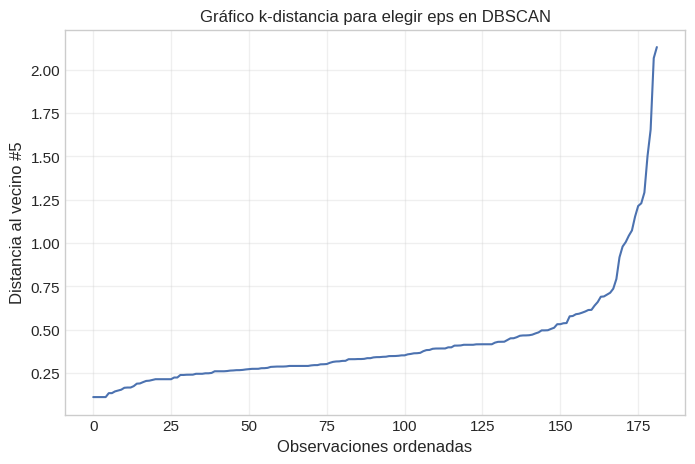

In [52]:
#Prueba Ultima:

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples_db = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_db)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Distancia al k-ésimo vecino
k_distances = np.sort(distances[:, min_samples_db-1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title('Gráfico k-distancia para elegir eps en DBSCAN')
plt.xlabel('Observaciones ordenadas')
plt.ylabel(f'Distancia al vecino #{min_samples_db}')
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

dbscan = DBSCAN(eps=0.7, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

print(pd.Series(labels_db).value_counts().sort_index())

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
if n_clusters_db >= 2:
    mask = labels_db != -1
    print("Silhouette DBSCAN:", round(silhouette_score(X_scaled[mask], labels_db[mask]), 3))
else:
    print("No hay suficientes clusters para calcular silhouette.")

-1     11
 0    171
Name: count, dtype: int64
No hay suficientes clusters para calcular silhouette.


In [54]:
def etiquetar_clusters_dinamico(df, cluster_col, variable_orden='log_MMR_2021'):
    resumen = (
        df[df[cluster_col] != -1]
        .groupby(cluster_col)[variable_orden]
        .mean()
        .sort_values()
    )

    etiquetas = {}
    clusters_ordenados = resumen.index.tolist()

    if len(clusters_ordenados) == 1:
        etiquetas[clusters_ordenados[0]] = 'Intermedio'
    elif len(clusters_ordenados) == 2:
        etiquetas[clusters_ordenados[0]] = 'Eficiente'
        etiquetas[clusters_ordenados[1]] = 'Crítico'
    elif len(clusters_ordenados) >= 3:
        etiquetas[clusters_ordenados[0]] = 'Eficiente'
        etiquetas[clusters_ordenados[-1]] = 'Crítico'
        for c in clusters_ordenados[1:-1]:
            etiquetas[c] = 'Transición'

    etiquetas[-1] = 'Atípico/Frontera'
    return etiquetas

In [55]:
mapa_hdb = etiquetar_clusters_dinamico(df_estudio, 'Cluster_HDBSCAN', 'log_MMR_2021')
df_estudio['Semaforo_HDBSCAN'] = df_estudio['Cluster_HDBSCAN'].map(mapa_hdb)

print(mapa_hdb)
df_estudio[['Country', 'Cluster_HDBSCAN', 'Semaforo_HDBSCAN']].head(20)

{1: 'Eficiente', 0: 'Crítico', -1: 'Atípico/Frontera'}


,Country,Cluster_HDBSCAN,Semaforo_HDBSCAN
0,Afghanistan,-1,Atípico/Frontera
1,Angola,-1,Atípico/Frontera
2,Albania,-1,Atípico/Frontera
4,United Arab Emirates,-1,Atípico/Frontera
5,Argentina,1,Eficiente
6,Armenia,1,Eficiente
7,Antigua and Barbuda,1,Eficiente
8,Australia,-1,Atípico/Frontera
9,Austria,-1,Atípico/Frontera
10,Azerbaijan,1,Eficiente


In [56]:
df_estudio['Cluster_DBSCAN'] = labels_db
mapa_db = etiquetar_clusters_dinamico(df_estudio, 'Cluster_DBSCAN', 'log_MMR_2021')
df_estudio['Semaforo_DBSCAN'] = df_estudio['Cluster_DBSCAN'].map(mapa_db)

print(mapa_db)

{0: 'Intermedio', -1: 'Atípico/Frontera'}


In [57]:
import hdbscan

hdb = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=3,
    cluster_selection_method='eom',
    prediction_data=True
)

labels_hdb = hdb.fit_predict(X_scaled)
df_estudio['Cluster_HDBSCAN'] = labels_hdb
df_estudio['Prob_HDBSCAN'] = hdb.probabilities_

print(pd.Series(labels_hdb).value_counts().sort_index())

-1    97
 0    10
 1    21
 2    16
 3    38
Name: count, dtype: int64


In [58]:
import hdbscan

hdb = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=3,
    cluster_selection_method='eom',
    prediction_data=True
)

labels_hdb = hdb.fit_predict(X_scaled)
df_estudio['Cluster_HDBSCAN'] = labels_hdb
df_estudio['Prob_HDBSCAN'] = hdb.probabilities_

print(pd.Series(labels_hdb).value_counts().sort_index())

-1    97
 0    10
 1    21
 2    16
 3    38
Name: count, dtype: int64


In [60]:
print(df_estudio.columns)

Index(['ISO3', 'Country', 'Continent', 'Hemisphere',
       'Human Development Groups', 'UNDP Developeing Regions',
       'HDI Rank (2021)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1990)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1991)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1992)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1993)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1994)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1995)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1996)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1997)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1998)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (1999)',
       'Maternal Mortality Ratio (deaths per 100,000 live births) (2000)',
       'Maternal Mortality Ratio 

In [62]:
df_ruido_hdb = df_estudio[df_estudio['Cluster_HDBSCAN'] == -1][[
    'Country',
    'UNDP Developeing Regions',
    'Cluster_HDBSCAN',
    'log_MMR_2021',
    'Brecha_Absoluta'
]].sort_values('Brecha_Absoluta', ascending=False)

df_ruido_hdb.head(25)

,Country,UNDP Developeing Regions,Cluster_HDBSCAN,log_MMR_2021,Brecha_Absoluta
160,South Sudan,SSA,-1,3.060698,1080.0
169,Chad,SSA,-1,3.056905,1070.0
155,Sierra Leone,SSA,-1,3.049218,1050.0
127,Nigeria,SSA,-1,2.962369,847.0
28,Central African Republic,SSA,-1,2.918555,759.0
121,Mauritania,SSA,-1,2.884229,696.0
66,Guinea-Bissau,SSA,-1,2.824126,597.0
98,Liberia,SSA,-1,2.820201,591.0
0,Afghanistan,SA,-1,2.804821,568.0
33,Ivory Coast,SSA,-1,2.790285,547.0


In [64]:
from sklearn.metrics import adjusted_rand_score

# Cambiamos 'Cluster_KMeans' por 'KMeans_Label'
ari_kmeans_hdb = adjusted_rand_score(df_estudio['KMeans_Label'], df_estudio['Cluster_HDBSCAN'])
ari_kmeans_db = adjusted_rand_score(df_estudio['KMeans_Label'], df_estudio['Cluster_DBSCAN'])

# Esta línea ya estaba bien porque usas Cluster_DBSCAN y Cluster_HDBSCAN
ari_db_hdb = adjusted_rand_score(df_estudio['Cluster_DBSCAN'], df_estudio['Cluster_HDBSCAN'])

print("ARI K-Means vs HDBSCAN:", round(ari_kmeans_hdb, 3))
print("ARI K-Means vs DBSCAN:", round(ari_kmeans_db, 3))
print("ARI DBSCAN vs HDBSCAN:", round(ari_db_hdb, 3))

ARI K-Means vs HDBSCAN: 0.106
ARI K-Means vs DBSCAN: 0.012
ARI DBSCAN vs HDBSCAN: -0.057


In [65]:
print(df_estudio.columns.tolist())

['ISO3', 'Country', 'Continent', 'Hemisphere', 'Human Development Groups', 'UNDP Developeing Regions', 'HDI Rank (2021)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1990)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1991)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1992)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1993)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1994)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1995)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1996)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1997)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1998)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1999)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (2000)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (2001)', 'Maternal Mortality Ratio (deaths per 100,000 live births) (20